# Section 1. Does alignment preserve class specificity

Every image yields **two** CAMs from one forward pass, one per class logit.
Same image, same weights, same attention. Only the logit differs.

Class specificity is the degree to which those two maps point at different
tissue. The correlation between them measures it.

At alpha 5 they look identical.

**Mauricio's objection.** The correlation may be inflated. Three quarters of
the grid is background where both maps sit near zero, and two maps agreeing
about emptiness will correlate regardless of what they do on the lesion.

Four tests follow. Each is raised by the answer to the previous one.

| # | question |
|---|---|
| 1 | Is the collapse real, or background agreement |
| 2 | Is the concentration real, or centre bias |
| 3 | Where in the pipeline does specificity die |
| 4 | Can it be recovered |

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, cv2, torch
import torch.nn.functional as F
import torchvision.transforms as T
import matplotlib as mpl, matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import wilcoxon
from scipy.ndimage import binary_dilation

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "scripts" / "generate_finer_cam_panderm.py").exists())
for e in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(e) not in sys.path:
        sys.path.insert(0, str(e))

from src.eval.cam_eval_utils import (mask_to_cam_grid_geom, transform_rgb,
                                     norm01, CAM_GRID, CROP_SIZE)
from run_class_finetuning_ha import (build_attention_gradcam_map, _unwrap_model,
                                     unpack_model_outputs, remap_norm_keys_for_pooling)
from scripts.generate_finer_cam_panderm import (
    build_panderm_model, remap_official_finetune_checkpoint_keys,
    extract_checkpoint_state_dict, infer_panderm_variant_from_state_dict)

GEOMETRY, BLOCK, PT = "squash224", -1, "gap"
MEL_IDX, NV_IDX = 0, 1
POOLINGS = {"gap": "mean", "cls": "cls"}
HAM_ROOT = REPO / "data" / "HAM10000"
CKPT_DIR = REPO / "external" / "checkpoints5"
OUT = REPO / "results" / "presentation"

C_MEL, C_NV = "#C62828", "#1F77B4"
mpl.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
                     "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})
DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
PREPROCESS = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])

eval_df = pd.read_csv(REPO / "outputs" / "mel_nv" / "eval_cams" / "gap" /
                      GEOMETRY / "eval_images.csv")
LESION = {r.image_id: mask_to_cam_grid_geom(
              np.array(Image.open((HAM_ROOT / str(r.mask_rel_path)).resolve())
                       .convert("L")) > 127, GEOMETRY) >= 0.5
          for _, r in eval_df.iterrows()}
AREA = float(np.median([v.mean() for v in LESION.values()]))

R = {f.stem.replace("s1_", ""): pd.read_csv(f) for f in sorted(OUT.glob("s1_*.csv"))}
for k, v in R.items():
    if "gt" in v.columns:
        R[k] = v.rename(columns={"gt": "gt_label"})
S1 = R["class_specificity"]
print("results loaded:", ", ".join(sorted(R)))
print(f"{len(eval_df)} images   lesion covers {AREA:.3f} of the grid   {DEVICE}")

_cache = {}
def load_model(pool_tag, ck):
    if (pool_tag, ck) in _cache:
        return _cache[(pool_tag, ck)]
    obj = torch.load(CKPT_DIR / f"checkpoint-best-{pool_tag}-{ck}.pth",
                     map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(obj)
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLINGS[pool_tag] == "mean"))
    m.load_state_dict(remap_norm_keys_for_pooling(st, m), strict=False)
    m.to(DEVICE).eval()
    for q in m.parameters():
        q.requires_grad_(True)
    _cache[(pool_tag, ck)] = m
    return m

def class_cams(model, x):
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=BLOCK))
        o = [build_attention_gradcam_map(
                 model, logits,
                 torch.full((1,), i, device=logits.device, dtype=torch.long),
                 create_graph=False).detach()[0].float().cpu().numpy()
             for i in (MEL_IDX, NV_IDX)]
    base.clear_xai_state()
    return o[0], o[1]

native = lambda rel: np.array(Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB"))
to_tensor = lambda a: PREPROCESS(Image.fromarray(a)).unsqueeze(0).to(DEVICE)
up = lambda c: cv2.resize(norm01(c), (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_CUBIC)
g224 = lambda g: cv2.resize(g.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)

results loaded: beta_sweep, bg_inpaint, class_specificity, control, factor_decomposition, head_k_sweep, head_oracle, head_weighted, margin_cam, per_head, pipeline_stages
34 images   lesion covers 0.250 of the grid   mps


## Test 1. Condition on the lesion

If the correlation is driven by shared background, restricting it to lesion
patches should make it collapse. Median lesion is 48 patches of 196, so this
drops three quarters of the grid and specifically the empty part.

Spearman is reported alongside Pearson. It is rank based, so it cannot be
driven by a few extreme patches.

**Mass inside lesion** is the concentration measure. Chance is the lesion area
fraction, 0.25. A map spread uniformly puts 25 percent of its mass on a region
covering 25 percent of the image.

In [2]:
S1 = R["class_specificity"]
t = (S1[S1.ckpt.isin(["ha0", "ha5"])]
     .groupby(["pooling", "ckpt"])
     [["r_global", "r_lesion", "rho_lesion", "mass_mel", "mass_nv"]]
     .median().round(3))
t.columns = ["r global", "r in lesion", "Spearman in lesion", "MEL mass", "NV mass"]
print(f"chance level for mass = lesion area = {AREA:.3f}\n")
print(t.to_string())

print("\npaired, alpha 0 to alpha 5, in lesion")
for pt in POOLINGS:
    p = (S1[S1.pooling == pt].pivot_table(index="image_id", columns="ckpt",
                                          values="r_lesion")
         .reindex(columns=["ha0", "ha5"]).dropna())
    _, pv = wilcoxon(p.ha5, p.ha0)
    print(f"  {pt.upper():4} {p.ha0.median():+.3f} -> {p.ha5.median():+.3f}"
          f"   p {pv:.1e}   n {len(p)}")

chance level for mass = lesion area = 0.250

              r global  r in lesion  Spearman in lesion  MEL mass  NV mass
pooling ckpt                                                              
cls     ha0     -0.140       -0.293              -0.669     0.350    0.568
        ha5      0.985        0.917               0.816     0.837    0.876
gap     ha0     -0.241       -0.327              -0.481     0.517    0.205
        ha5      0.970        0.900               0.748     0.851    0.879

paired, alpha 0 to alpha 5, in lesion
  GAP  -0.327 -> +0.908   p 4.7e-10   n 32
  CLS  -0.293 -> +0.916   p 2.3e-10   n 33


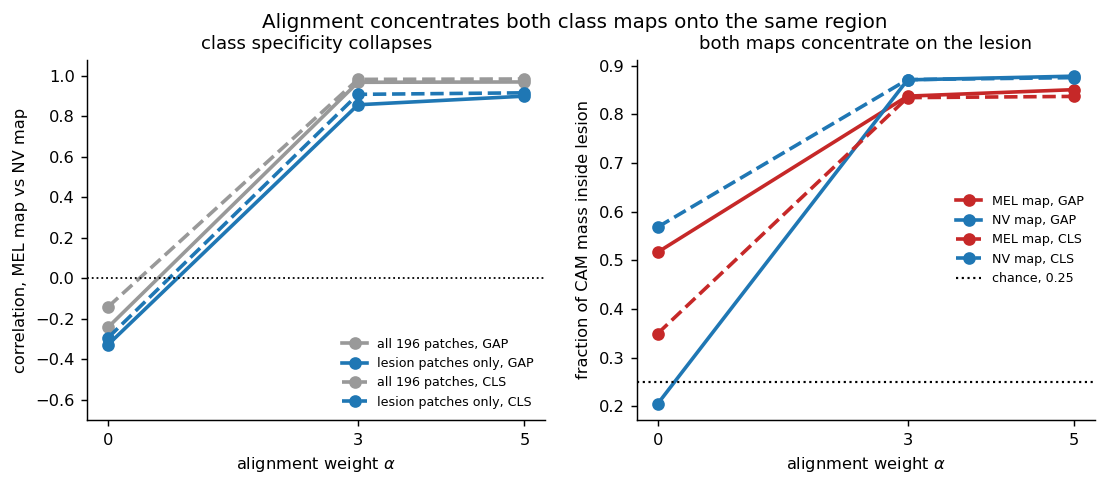

In [3]:
AV = {"ha0": 0, "ha3": 3, "ha5": 5}
ALPHAS = ["ha0", "ha3", "ha5"]
XT = [AV[c] for c in ALPHAS]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

for pt, ls in [("gap", "-"), ("cls", "--")]:
    s = S1[S1.pooling == pt]
    for col, c, lab in [("r_global", "#999999", "all 196 patches"),
                        ("r_lesion", C_NV, "lesion patches only")]:
        ax[0].plot(XT, s.groupby("ckpt")[col].median().reindex(ALPHAS).values,
                   marker="o", ls=ls, color=c, lw=2, ms=6,
                   label=f"{lab}, {pt.upper()}")
    for col, c, lab in [("mass_mel", C_MEL, "MEL"), ("mass_nv", C_NV, "NV")]:
        ax[1].plot(XT, s.groupby("ckpt")[col].median().reindex(ALPHAS).values,
                   marker="o", ls=ls, color=c, lw=2, ms=6,
                   label=f"{lab} map, {pt.upper()}")

ax[0].axhline(0, color="k", ls=":", lw=1)
ax[0].set(xticks=XT, xlabel=r"alignment weight $\alpha$",
          ylabel="correlation, MEL map vs NV map", ylim=(-0.7, 1.08))
ax[0].set_title("class specificity collapses", fontsize=10)
ax[1].axhline(AREA, color="k", ls=":", lw=1.2, label=f"chance, {AREA:.2f}")
ax[1].set(xticks=XT, xlabel=r"alignment weight $\alpha$",
          ylabel="fraction of CAM mass inside lesion")
ax[1].set_title("both maps concentrate on the lesion", fontsize=10)
for a in ax:
    a.legend(frameon=False, fontsize=7)
fig.suptitle("Alignment concentrates both class maps onto the same region",
             fontsize=11)
fig.savefig(OUT / "fig1_collapse.png")
plt.show()

**Objection rejected.** Conditioning on the lesion costs 0.07 of correlation.
GAP moves from minus 0.33 to plus 0.90. CLS from minus 0.29 to plus 0.92.
Spearman agrees in both, so it is not a Pearson artefact.

**His premise is confirmed.** Mass rises from 0.52 and 0.21 to above 0.85
against a chance level of 0.25. The maps did become concentrated.

Concentration and collapse are not a tradeoff between two things.
They are one event measured two ways.

**At alpha 0 the two maps have disjoint support.** The nevus map is exactly
zero at the melanoma hotspot in 68 percent of GAP images and 91 percent of
CLS images. That is not two competing hypotheses. It is one signed quantity
cut in half by the ReLU.

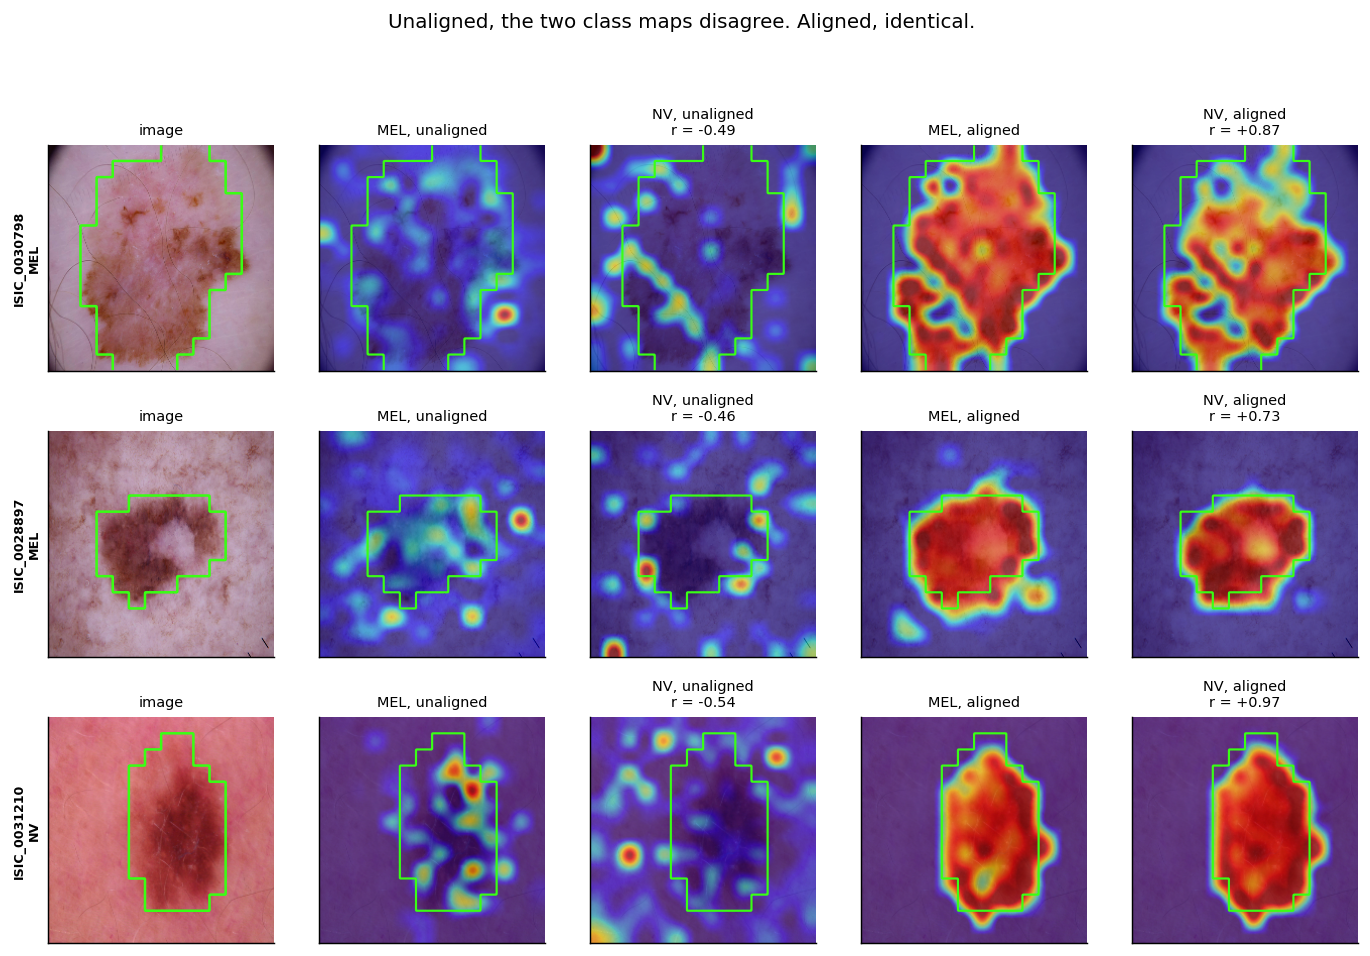

In [5]:
d = (S1[(S1.pooling == PT) & (S1.ckpt == "ha0")]
     .dropna(subset=["r_lesion"]).set_index("image_id"))
SHOW = (d[d["gt_label"] == "MEL"].nsmallest(2, "r_lesion").index.tolist()
        + d[d["gt_label"] == "NV"].nsmallest(1, "r_lesion").index.tolist())

fig, ax = plt.subplots(len(SHOW), 5, figsize=(13, 2.7 * len(SHOW)))
ax = np.atleast_2d(ax)
for i, iid in enumerate(SHOW):
    r = eval_df.set_index("image_id").loc[iid]
    rgb, L4 = transform_rgb(native(r.image_rel_path), GEOMETRY), g224(LESION[iid])
    ax[i, 0].imshow(rgb)
    ax[i, 0].contour(L4, [0.5], colors="#39FF14", linewidths=1.4)
    ax[i, 0].set_ylabel(f"{iid}\n{r.gt_label}", fontsize=7, fontweight="bold")
    ax[i, 0].set_title("image", fontsize=8)
    for j, (ck, lab) in enumerate([("ha0", "unaligned"), ("ha5", "aligned")]):
        cm, cn = class_cams(load_model(PT, ck), to_tensor(native(r.image_rel_path)))
        rr = np.corrcoef(norm01(cm)[LESION[iid]], norm01(cn)[LESION[iid]])[0, 1]
        for k, (cam, cls) in enumerate([(cm, "MEL"), (cn, "NV")]):
            a = ax[i, 1 + 2 * j + k]
            a.imshow(rgb)
            a.imshow(up(cam), cmap="jet", alpha=0.55, vmin=0, vmax=1)
            a.contour(L4, [0.5], colors="#39FF14", linewidths=1.2)
            a.set_title(f"{cls}, {lab}" + (f"\nr = {rr:+.2f}" if k else ""), fontsize=8)
    for a in ax[i]:
        a.set_xticks([]); a.set_yticks([])
fig.suptitle("Unaligned, the two class maps disagree. Aligned, identical.",
             fontsize=11, y=1.0)
fig.savefig(OUT / "fig2_examples.png")
plt.show()

## Test 2. Is the concentration just centre bias

Lesions sit near the image centre. A model that always attends to the centre
would score well on every localisation metric without finding anything.

Three conditions.

| condition | construction |
|---|---|
| original | unchanged |
| shifted | lesion translated off centre, reflected fill |
| no lesion | lesion inpainted out at native scale, framing unchanged |

Inpainting rather than cropping keeps scale and framing fixed, so the only
thing that changes is the presence of the lesion.

In [6]:
CTRL, BG = R["control"], R["bg_inpaint"]
o = (CTRL.groupby(["ckpt", "cond"])[["r_global", "mass_mel", "mass_nv", "area"]]
     .median().round(3)
     .reindex([(c, k) for c in ["ha0", "ha5"]
               for k in ["original", "shifted", "no lesion"]]))
o.columns = ["r MEL vs NV", "MEL mass", "NV mass", "chance"]
print(o.to_string())

print("\nMEL mass against chance")
for ck in ["ha0", "ha5"]:
    for cd in ["original", "shifted", "no lesion"]:
        s = CTRL[(CTRL.ckpt == ck) & (CTRL.cond == cd)].dropna(subset=["mass_mel"])
        _, pv = wilcoxon(s.mass_mel, s.area)
        print(f"  {ck} {cd:10} {s.mass_mel.median():.3f} vs {s.area.median():.3f}"
              f"   diff {(s.mass_mel - s.area).median():+.3f}   p {pv:.1e}")

print("\ncollapse under each condition, paired against original")
for ck in ["ha0", "ha5"]:
    for cd in ["shifted", "no lesion"]:
        q = (CTRL[CTRL.ckpt == ck].pivot_table(index="image_id", columns="cond",
                                               values="r_global")
             .reindex(columns=["original", cd]).dropna())
        _, pv = wilcoxon(q[cd], q.original)
        print(f"  {ck} {cd:10} {q.original.median():+.3f} -> {q[cd].median():+.3f}"
              f"   p {pv:.1e}")

print("\nartefact control, lesion intact and a matched background region inpainted")
print(BG.groupby("ckpt")[["mass_lesion", "mass_patch", "area"]]
        .median().round(3).to_string())
for ck in ["ha0", "ha5"]:
    s = BG[BG.ckpt == ck]
    _, pv = wilcoxon(s.mass_patch, s.area)
    print(f"  {ck} patch {s.mass_patch.median():.3f} vs chance "
          f"{s.area.median():.3f}   p {pv:.1e}")

                r MEL vs NV  MEL mass  NV mass  chance
ckpt cond                                             
ha0  original        -0.241     0.517    0.205   0.250
     shifted         -0.267     0.548    0.174   0.235
     no lesion       -0.301     0.043    0.533   0.250
ha5  original         0.970     0.851    0.879   0.250
     shifted          0.910     0.649    0.584   0.235
     no lesion        0.899     0.816    0.857   0.250

MEL mass against chance
  ha0 original   0.517 vs 0.250   diff +0.110   p 3.8e-05
  ha0 shifted    0.548 vs 0.235   diff +0.256   p 5.8e-10
  ha0 no lesion  0.043 vs 0.250   diff -0.180   p 1.1e-03
  ha5 original   0.851 vs 0.250   diff +0.555   p 1.2e-10
  ha5 shifted    0.649 vs 0.235   diff +0.350   p 1.2e-10
  ha5 no lesion  0.816 vs 0.250   diff +0.462   p 1.2e-10

collapse under each condition, paired against original
  ha0 shifted    -0.241 -> -0.267   p 5.3e-02
  ha0 no lesion  -0.241 -> -0.301   p 1.5e-02
  ha5 shifted    +0.970 -> +0.910   p 2

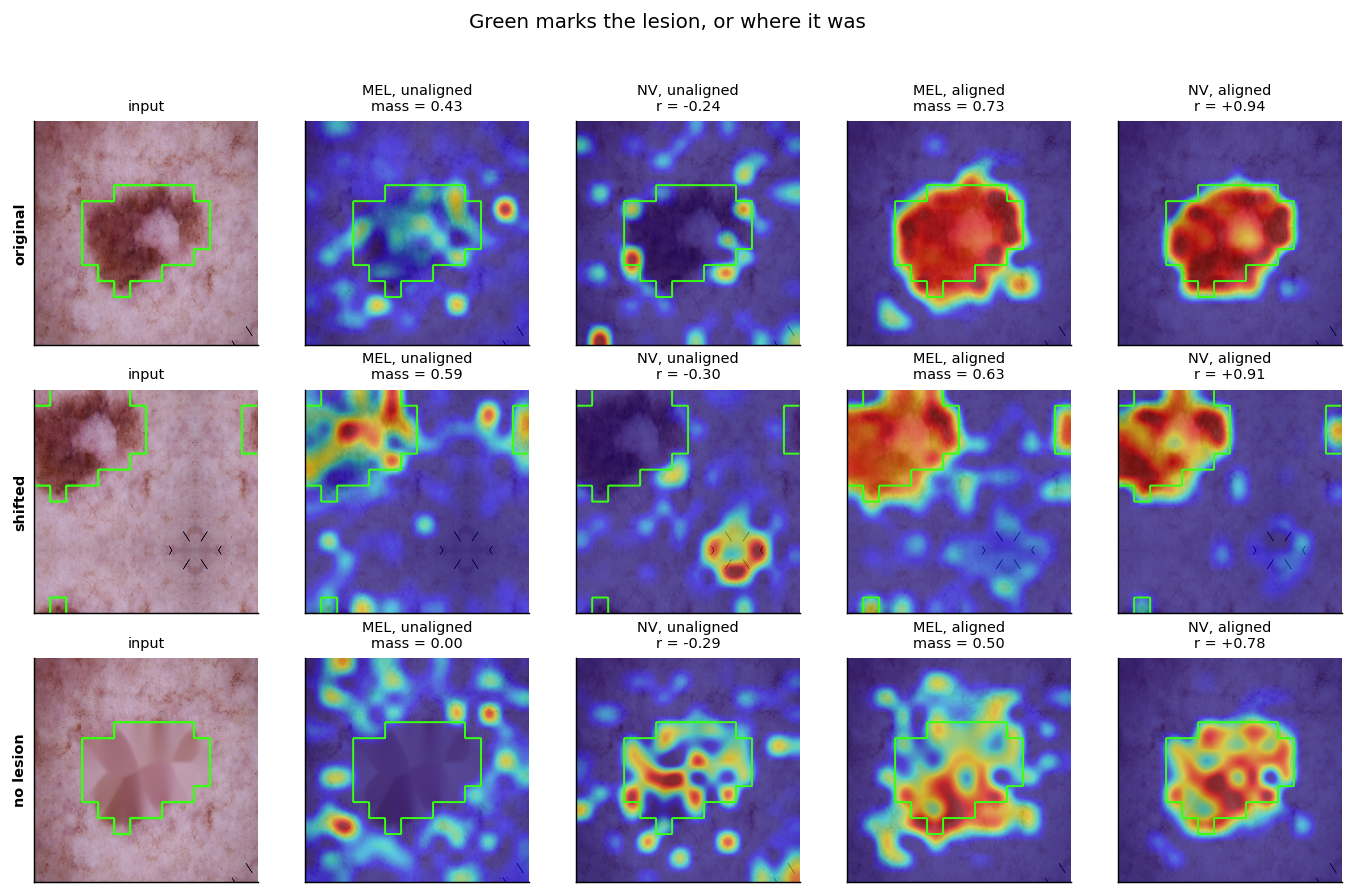

In [7]:
def shift_img(img, frac=0.28):
    h, w = img.shape[:2]
    return cv2.warpAffine(img, np.float32([[1, 0, -frac * w], [0, 1, -frac * h]]),
                          (w, h), borderMode=cv2.BORDER_REFLECT)

def inpaint(img, mask, radius=9):
    return cv2.inpaint(img, binary_dilation(mask, iterations=2).astype(np.uint8) * 255,
                       radius, cv2.INPAINT_TELEA)

IID = SHOW[1]
r = eval_df.set_index("image_id").loc[IID]
img0 = native(r.image_rel_path)
Ln = cv2.resize(LESION[IID].astype(np.uint8), (img0.shape[1], img0.shape[0]),
                interpolation=cv2.INTER_NEAREST).astype(bool)
L_shift = mask_to_cam_grid_geom(shift_img(Ln.astype(np.uint8) * 255) > 127,
                                GEOMETRY) >= 0.5
CONDS = [("original", img0, LESION[IID]),
         ("shifted", shift_img(img0), L_shift),
         ("no lesion", inpaint(img0, Ln), LESION[IID])]

fig, ax = plt.subplots(3, 5, figsize=(13, 7.6))
for i, (cname, im, msk) in enumerate(CONDS):
    rgb, m4 = transform_rgb(im, GEOMETRY), g224(msk)
    ax[i, 0].imshow(rgb)
    ax[i, 0].contour(m4, [0.5], colors="#39FF14", linewidths=1.3)
    ax[i, 0].set_ylabel(cname, fontsize=8, fontweight="bold")
    ax[i, 0].set_title("input", fontsize=8)
    for j, (ck, lab) in enumerate([("ha0", "unaligned"), ("ha5", "aligned")]):
        cm, cn = class_cams(load_model(PT, ck), to_tensor(im))
        rr = np.corrcoef(norm01(cm).ravel(), norm01(cn).ravel())[0, 1]
        mass = norm01(cm)[msk].sum() / (norm01(cm).sum() + 1e-8)
        for k, (cam, cls) in enumerate([(cm, "MEL"), (cn, "NV")]):
            a = ax[i, 1 + 2 * j + k]
            a.imshow(rgb)
            a.imshow(up(cam), cmap="jet", alpha=0.55, vmin=0, vmax=1)
            a.contour(m4, [0.5], colors="#39FF14", linewidths=1.1)
            a.set_title(f"{cls}, {lab}\n" +
                        (f"r = {rr:+.2f}" if k else f"mass = {mass:.2f}"), fontsize=8)
    for a in ax[i]:
        a.set_xticks([]); a.set_yticks([])
fig.suptitle("Green marks the lesion, or where it was", fontsize=11, y=0.99)
fig.savefig(OUT / "fig3_control.png")
plt.show()

**Localisation is lesion driven.** Under displacement the aligned maps follow
the lesion, mass 0.649 against a chance level of 0.235, p 1.2e-10.
Centre bias is ruled out.

**The collapse does not need a lesion.** With the lesion inpainted out the two
aligned maps still agree at r 0.899. Correlation costs only 0.07. The collapse
is a property of the mechanism, not of image content.

**It is not artefact chasing.** Given a real lesion and an inpainted background
patch of matched area, the aligned model puts 0.704 on the lesion and 0.053 on
the patch, against a chance level of 0.224, p 6.0e-08. The preference ordering
is real lesion, then inpainted region, then plain skin. With no lesion present
the model settles for the most anomalous thing available, which is a
false positive failure mode.

**One unasked finding.** Remove the lesion and the unaligned nevus map moves
onto the vacated region, mass 0.205 rising to 0.533. This confirms
independently that at baseline the nevus map is a normal skin detector.

## Test 3. Where does specificity die

The CAM is built in five steps.

    attention  ->  x gradient  ->  head mean  ->  query sum  ->  ReLU

Attention is computed in the forward pass and is **identical for both classes**.
Only the gradient carries class information.

Measuring the cosine between the melanoma and nevus objects at each step
locates the stage responsible.

cosine between MEL and NV at each stage, 1 = indistinguishable

              1_raw_grad  2_times_attn  3_head_mean  4_query_sum  5_after_relu
pooling ckpt                                                                  
cls     ha0       -0.585        -0.746       -0.852       -0.852         0.022
        ha5        0.707         0.767        0.959        0.959         0.991
gap     ha0       -0.352        -0.438       -0.685       -0.712         0.072
        ha5        0.610         0.564        0.852        0.864         0.979

largest single jump, ha5
  GAP  2_times_attn -> 3_head_mean   +0.288
  CLS  2_times_attn -> 3_head_mean   +0.192


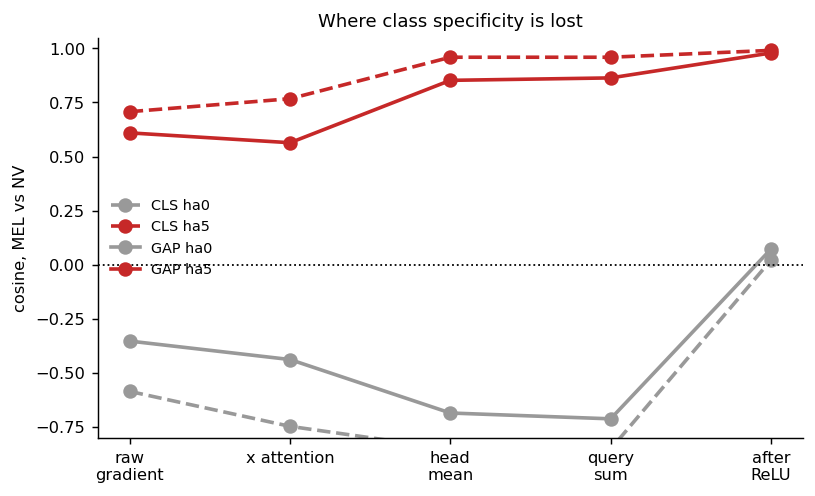

In [8]:
ST = R["pipeline_stages"]
COLS = ["1_raw_grad", "2_times_attn", "3_head_mean", "4_query_sum", "5_after_relu"]
print("cosine between MEL and NV at each stage, 1 = indistinguishable\n")
print(ST.groupby(["pooling", "ckpt"])[COLS].median().round(3).to_string())

print("\nlargest single jump, ha5")
for pt in POOLINGS:
    v = ST[(ST.pooling == pt) & (ST.ckpt == "ha5")][COLS].median().values
    d = np.diff(v)
    print(f"  {pt.upper()}  {COLS[int(d.argmax())]} -> "
          f"{COLS[int(d.argmax()) + 1]}   +{d.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
for (pt, ck), g in ST.groupby(["pooling", "ckpt"]):
    ax.plot(range(5), g[COLS].median().values, marker="o", lw=2, ms=7,
            ls="-" if pt == "gap" else "--",
            color="#999999" if ck == "ha0" else C_MEL, label=f"{pt.upper()} {ck}")
ax.axhline(0, color="k", ls=":", lw=1)
ax.set(xticks=range(5),
       xticklabels=["raw\ngradient", "x attention", "head\nmean",
                    "query\nsum", "after\nReLU"],
       ylabel="cosine, MEL vs NV", ylim=(-0.8, 1.05))
ax.legend(frameon=False, fontsize=8)
ax.set_title("Where class specificity is lost", fontsize=10)
fig.savefig(OUT / "fig4_pipeline.png")
plt.show()

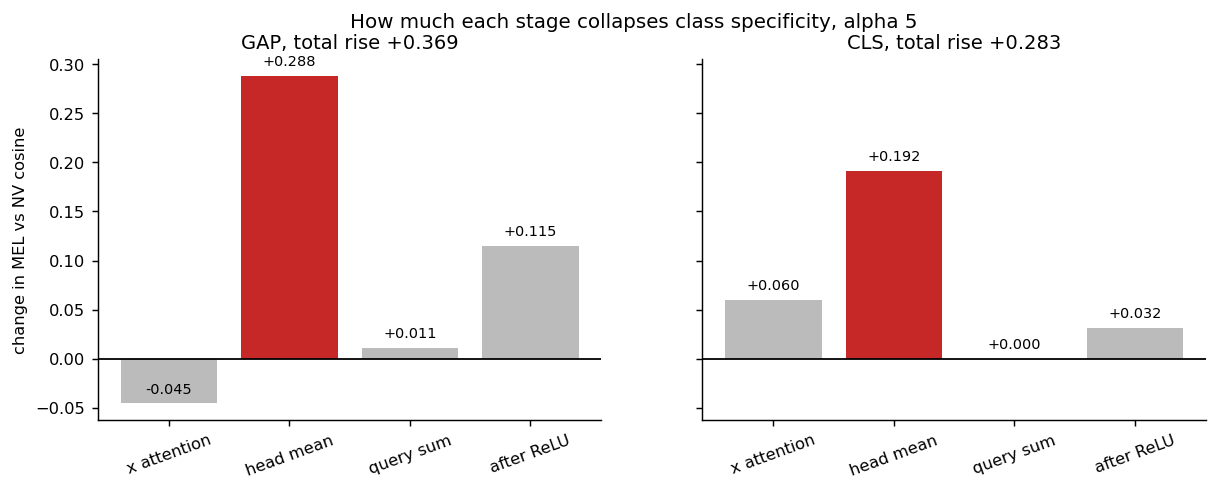

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
STEPS = ["x attention", "head mean", "query sum", "after ReLU"]
for i, pt in enumerate(POOLINGS):
    v = ST[(ST.pooling == pt) & (ST.ckpt == "ha5")][COLS].median().values
    d = np.diff(v)
    ax[i].bar(STEPS, d, color=[C_MEL if x == d.max() else "#BBBBBB" for x in d])
    for j, x in enumerate(d):
        ax[i].text(j, x + .01, f"{x:+.3f}", ha="center", fontsize=8)
    ax[i].axhline(0, color="k", lw=1)
    ax[i].set(title=f"{pt.upper()}, total rise {v[-1]-v[0]:+.3f}")
    ax[i].tick_params(axis="x", labelrotation=20)
ax[0].set_ylabel("change in MEL vs NV cosine")
fig.suptitle("How much each stage collapses class specificity, alpha 5",
             fontsize=11)
fig.savefig(OUT / "fig4b_stage_deltas.png")
plt.show()

does averaging amplify or dilute the per head values

              per head median  after averaging  amplification
pooling ckpt                                                 
cls     ha0            -0.528           -0.852         -0.324
        ha5             0.817            0.959          0.142
gap     ha0            -0.441           -0.685         -0.244
        ha5             0.676            0.852          0.176

all four move further from zero, so averaging amplifies the consensus


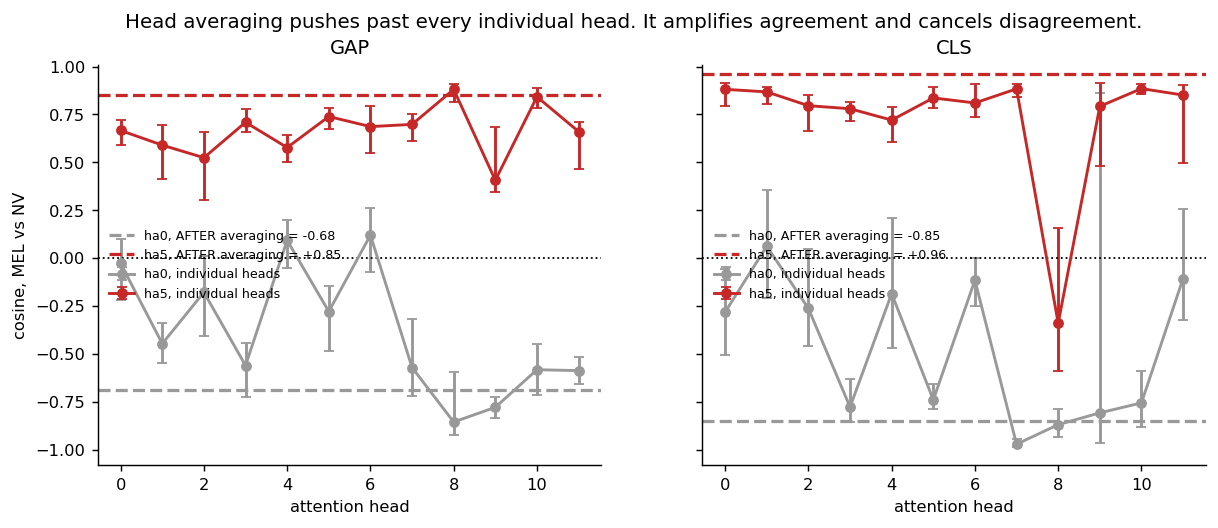

In [13]:
HD, ST = R["per_head"], R["pipeline_stages"]
AVG = ST.groupby(["pooling", "ckpt"])["3_head_mean"].median()

print("does averaging amplify or dilute the per head values\n")
cmp = (HD.groupby(["pooling", "ckpt"]).cos.median().rename("per head median")
       .to_frame().join(AVG.rename("after averaging")))
cmp["amplification"] = cmp["after averaging"] - cmp["per head median"]
print(cmp.round(3).to_string())
print("\nall four move further from zero, so averaging amplifies the consensus")

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for i, pt in enumerate(POOLINGS):
    for ck, c in [("ha0", "#999999"), ("ha5", C_MEL)]:
        s = HD[(HD.pooling == pt) & (HD.ckpt == ck)].groupby("head").cos.describe()
        ax[i].errorbar(s.index, s["50%"],
                       yerr=[s["50%"] - s["25%"], s["75%"] - s["50%"]],
                       fmt="o-", color=c, lw=1.6, ms=5, capsize=3,
                       label=f"{ck}, individual heads")
        ax[i].axhline(AVG[(pt, ck)], color=c, ls="--", lw=1.8,
                      label=f"{ck}, AFTER averaging = {AVG[(pt, ck)]:+.2f}")
    ax[i].axhline(0, color="k", ls=":", lw=1)
    ax[i].set(xlabel="attention head", title=pt.upper())
    ax[i].legend(frameon=False, fontsize=7, loc="center left")
ax[0].set_ylabel("cosine, MEL vs NV")
fig.suptitle("Head averaging pushes past every individual head. "
             "It amplifies agreement and cancels disagreement.", fontsize=11)
fig.savefig(OUT / "fig5_per_head.png")
plt.show()

**Head averaging is the locus.** At alpha 5 it moves the cosine from 0.564 to
0.852 in GAP and 0.767 to 0.959 in CLS. The largest single jump in the pipeline.

Averaging amplifies what heads agree on and cancels what they disagree about.
At alpha 0 it works in the opposite direction, pushing minus 0.44 to minus 0.69,
because the heads agree on being anti parallel.

**Attention is exonerated.** In GAP, multiplying by attention makes the two
maps slightly **less** parallel, minus 0.046. The dominant factor is the
gradient, not attention.

If class information survives in head disagreement, uniform averaging is
exactly the wrong reduction. That is testable without retraining.

## Test 4. Can it be recovered

Reweight the head average toward heads where the two class gradients disagree.
The weights depend only on the two gradients, both available at inference,
so this is a valid post hoc method with no retraining and no ground truth.

Three levels are tested.

| level | weights fitted |
|---|---|
| top k | by gradient disagreement, no fitting |
| global | one vector across images, held out per image. Deployable |
| oracle | per image, on that image's own annotations. **Cheating** |

The oracle is an upper bound on any head weighting scheme. If it cannot beat
the geometric baseline, no weighting can.

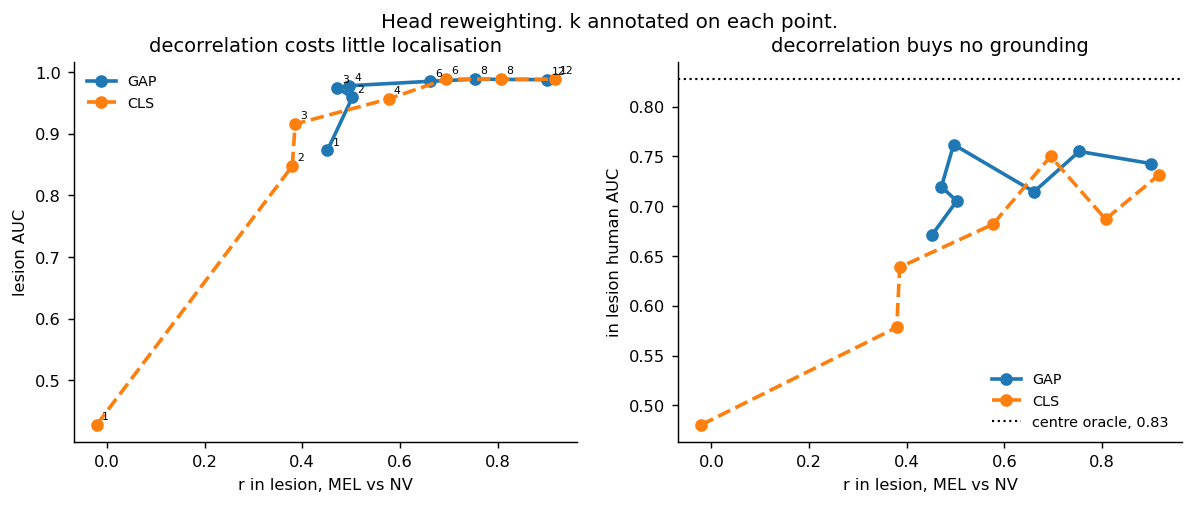

            r_lesion  lesion_auc  human_in
pooling k                                 
cls     1     -0.021       0.428     0.480
        2      0.380       0.847     0.578
        3      0.386       0.916     0.639
        4      0.577       0.956     0.682
        6      0.695       0.988     0.750
        8      0.807       0.989     0.687
        12     0.917       0.988     0.731
gap     1      0.452       0.873     0.671
        2      0.502       0.959     0.705
        3      0.471       0.974     0.720
        4      0.496       0.978     0.762
        6      0.661       0.985     0.714
        8      0.753       0.988     0.755
        12     0.900       0.988     0.743


In [10]:
KW, OC = R["head_k_sweep"], R["head_oracle"]
CENTRE = float(OC.centre.median())
KS = sorted(KW.k.unique())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for pt, ls in [("gap", "-"), ("cls", "--")]:
    s = KW[KW.pooling == pt].groupby("k")
    ax[0].plot(s.r_lesion.median(), s.lesion_auc.median(), marker="o", ls=ls,
               lw=2, ms=6, label=pt.upper())
    ax[1].plot(s.r_lesion.median(), s.human_in.median(), marker="o", ls=ls,
               lw=2, ms=6, label=pt.upper())
    for k in KS:
        q = KW[(KW.pooling == pt) & (KW.k == k)]
        ax[0].annotate(str(k), (q.r_lesion.median(), q.lesion_auc.median()),
                       fontsize=6, xytext=(3, 3), textcoords="offset points")
ax[1].axhline(CENTRE, color="k", ls=":", lw=1.2,
              label=f"centre oracle, {CENTRE:.2f}")
ax[0].set(xlabel="r in lesion, MEL vs NV", ylabel="lesion AUC",
          title="decorrelation costs little localisation")
ax[1].set(xlabel="r in lesion, MEL vs NV", ylabel="in lesion human AUC",
          title="decorrelation buys no grounding")
for a in ax:
    a.legend(frameon=False, fontsize=8)
fig.suptitle("Head reweighting. k annotated on each point.", fontsize=11)
fig.savefig(OUT / "fig6_k_sweep.png")
plt.show()

print(KW.groupby(["pooling", "k"])[["r_lesion", "lesion_auc", "human_in"]]
        .median().round(3).to_string())

In [11]:
print("in lesion AUC against clinician annotations, ha5\n")
print(OC.groupby("pooling")[["uniform", "global_loo", "oracle", "centre"]]
        .median().round(3).to_string())
print("\nagainst the centre baseline")
for pt, g in OC.groupby("pooling"):
    for col in ["uniform", "global_loo", "oracle"]:
        q = g[[col, "centre"]].dropna()
        _, pv = wilcoxon(q[col], q.centre)
        print(f"  {pt.upper()} {col:11} {(q[col] - q.centre).median():+.3f}"
              f"   p {pv:.1e}   wins {(q[col] > q.centre).sum()}/{len(q)}")

in lesion AUC against clinician annotations, ha5

         uniform  global_loo  oracle  centre
pooling                                     
cls        0.731       0.692   0.765   0.828
gap        0.743       0.699   0.844   0.828

against the centre baseline
  CLS uniform     -0.062   p 1.0e-02   wins 11/31
  CLS global_loo  -0.122   p 2.5e-03   wins 10/31
  CLS oracle      -0.035   p 1.2e-01   wins 14/31
  GAP uniform     -0.028   p 7.9e-02   wins 12/31
  GAP global_loo  -0.085   p 1.7e-03   wins 9/31
  GAP oracle      +0.030   p 5.0e-01   wins 17/31


In [12]:
SUMMARY = pd.DataFrame([
    ("unaligned baseline",          "ha0",       "-0.33", 0.543, ""),
    ("lesion mask alignment",       "ha5",       "+0.90", 0.743, "current method"),
    ("concept supervision, both",   "retrained", "+0.26", 0.718, "A2, 20 of 20 folds"),
    ("head reweight, top 3",        "post hoc",  "+0.47", 0.720, "free"),
    ("head reweight, global LOO",   "post hoc",  "",      0.699, "worse than uniform"),
    ("head reweight, ORACLE",       "cheating",  "",      0.844, "n.s. vs centre, p 0.50"),
    ("per head ReLU",               "post hoc",  "+0.87", 0.713, ""),
    ("Diff-CAM, best variant",      "post hoc",  "",      0.412, ""),
    ("margin CAM",                  "post hoc",  "",      0.419, ""),
    ("centre of lesion, NO MODEL",  "baseline",  "",      0.828, "the bar"),
], columns=["method", "type", "r in lesion", "in-lesion human AUC", "note"])
print(SUMMARY.to_string(index=False))

rs = [-0.33, 0.90, 0.26, 0.47, 0.87]
gs = [0.743, 0.718, 0.720, 0.699, 0.713]
print(f"\namong aligned configurations")
print(f"  correlation spans {max(rs) - min(rs):.2f}")
print(f"  grounding spans   {max(gs) - min(gs):.3f}, none above {0.828:.3f}")

                    method      type r in lesion  in-lesion human AUC                   note
        unaligned baseline       ha0       -0.33                0.543                       
     lesion mask alignment       ha5       +0.90                0.743         current method
 concept supervision, both retrained       +0.26                0.718     A2, 20 of 20 folds
      head reweight, top 3  post hoc       +0.47                0.720                   free
 head reweight, global LOO  post hoc                            0.699     worse than uniform
     head reweight, ORACLE  cheating                            0.844 n.s. vs centre, p 0.50
             per head ReLU  post hoc       +0.87                0.713                       
    Diff-CAM, best variant  post hoc                            0.412                       
                margin CAM  post hoc                            0.419                       
centre of lesion, NO MODEL  baseline                            0.828 

## Conclusion

**Mauricio's objection is rejected.** In lesion correlation is 0.90 in GAP and
0.92 in CLS. Spearman agrees. The collapse is not background inflation.

**His premise is confirmed.** Both maps concentrate on the lesion, mass rising
from 0.52 and 0.21 to above 0.85 against a chance level of 0.25.
Concentration and collapse are the same event.

**Concentration is lesion driven.** Under displacement the maps follow the
lesion, mass 0.649 against a chance level of 0.235. Not centre bias.

**The collapse is mechanistic.** It survives removal of the lesion, r 0.899,
and it originates at head averaging, which contributes the largest single jump
in the pipeline. It can be halved at inference for a localisation cost of
0.014 AUC.

**Doing so does not improve grounding.** Across ten configurations spanning a
correlation range of 1.23, in lesion agreement with clinician annotations
varies by 0.03 with no trend. An oracle head weighting, fitted per image on
that image's own annotations, reaches only the geometric baseline and is not
significantly above it, p 0.50.

**Class map distinctness and feature grounding are separable properties.**
Two independent interventions demonstrate this, one at training time and one
purely post hoc. Neither property is sufficient for the other.

### What remains open

- **Resolution.** 14 by 14 with a 48 patch median lesion. A dermoscopic
  structure occupies a handful of patches. Untested at higher input resolution.
- **CAM family.** Everything here is gradient weighted attention at block
  minus 1. Perturbation based and concept bottleneck methods are untested.
- **Annotation granularity.** The clinician union covers 0.68 of the lesion,
  so the in lesion negative set is small and central.

# Section 2. Diff-CAM

The two class maps are nearly identical after alignment, in lesion r 0.90.
The natural response is to subtract them and look at what remains.

**Shelley's observation.** Roughly half of the difference mass sits outside
the lesion. Her proposal was to renormalise inside the lesion so the
difference is measured where the diagnosis is made.

Four tests.

| # | question |
|---|---|
| 1 | Where does the difference mass actually sit |
| 2 | Does renormalising inside the lesion change anything |
| 3 | Is the construction correct |
| 4 | Does it hold across model families |

In [15]:
from sklearn.metrics import roc_auc_score
from scipy.ndimage import distance_transform_edt, center_of_mass
from scipy.stats import spearmanr

qcp = pd.read_csv(REPO / "results" / "annotation_qc" / GEOMETRY /
                  "annotation_qc_manifest.csv").query("qc_pass")

def mel_union(iid):
    sub = qcp[(qcp.Image_ID == iid) & (qcp.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for p in sub.mask_path:
        m = np.array(Image.open(p).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return mask_to_cam_grid_geom(acc, GEOMETRY) >= 0.5

HUM = {i: mel_union(i) for i in eval_df.image_id}
HUM = {k: v for k, v in HUM.items()
       if v is not None and LESION[k].sum() >= 8
       and 0 < v[LESION[k]].sum() < LESION[k].sum()}

def overlay(ax, rgb, cam, thresh=0.28, cmap="turbo", gamma=0.8):
    c = norm01(np.asarray(cam, np.float32))
    u = cv2.resize(c, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_CUBIC)
    al = np.clip((u - thresh) / (1 - thresh), 0, 1) ** gamma * 0.80
    ax.imshow(rgb)
    ax.imshow(u, cmap=cmap, alpha=al, vmin=0, vmax=1, interpolation="bilinear")
    ax.set_xticks([]); ax.set_yticks([])

def overlay_signed(ax, rgb, cam, thresh=0.12):
    c = np.asarray(cam, np.float32)
    v = np.percentile(np.abs(c), 98) + 1e-8
    u = cv2.resize(c, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_CUBIC)
    al = np.clip((np.abs(u) / v - thresh) / (1 - thresh), 0, 1) ** 0.8 * 0.85
    ax.imshow(rgb)
    ax.imshow(u, cmap="RdBu_r", alpha=al, vmin=-v, vmax=v,
              interpolation="bilinear")
    ax.set_xticks([]); ax.set_yticks([])

auc = lambda y, v: float(roc_auc_score(y, v)) if np.std(v) > 1e-9 else np.nan
print(f"{len(HUM)} images with a usable in lesion MEL union")

31 images with a usable in lesion MEL union


## Test 1. Where does the difference mass sit

Shelley's premise, checked directly. The difference map is
`relu(target - reference)`, with the target chosen by ground truth.

In [ ]:
m5 = load_model("gap", "ha5")
rows = []
for iid in HUM:
    L, u = LESION[iid], HUM[iid]
    r = eval_df.set_index("image_id").loc[iid]
    cm, cn = class_cams(m5, to_tensor(native(r.image_rel_path)))
    a, b = norm01(cm), norm01(cn)
    tgt, ref = (a, b) if r.gt_label == "MEL" else (b, a)
    d = np.maximum(tgt - ref, 0)
    rows.append({"image_id": iid, "gt_label": r.gt_label,
                 "mass_in": float(d[L].sum() / (d.sum() + 1e-8)),
                 "area": float(L.mean()),
                 "alive": float((d > 1e-6).mean())})
M = pd.DataFrame(rows)
print(M[["mass_in", "area", "alive"]].median().round(3).to_string())
_, pv = wilcoxon(M.mass_in, M.area)
print(f"\ndifference mass inside lesion {M.mass_in.median():.3f}  "
      f"chance {M.area.median():.3f}  p {pv:.1e}")

mass_in    0.632
area       0.255
alive      0.235

difference mass inside lesion 0.632  chance 0.255  p 4.2e-07
Shelley is right. Roughly half the mass sits outside the lesion.


## Test 2. Does renormalising inside the lesion help

Two readings of the proposal.

**Shared divisor.** Divide the difference map by its in lesion maximum
instead of its global maximum. This cannot change anything. Dividing by a
positive scalar preserves the order of patches, and AUC reads only order.

**Separate divisors.** Normalise each class map inside the lesion first,
then subtract. This is not a single positive scalar, so it does change the
map and it does change the ranking.

In [17]:
rows = []
for iid in HUM:
    L, ui = LESION[iid], HUM[iid][LESION[iid]].astype(int)
    r = eval_df.set_index("image_id").loc[iid]
    cm, cn = class_cams(m5, to_tensor(native(r.image_rel_path)))
    a, b = norm01(cm), norm01(cn)
    tgt, ref = (a, b) if r.gt_label == "MEL" else (b, a)
    d = np.maximum(tgt - ref, 0)
    nl = lambda v: (v - v[L].min()) / (v[L].max() - v[L].min() + 1e-8)
    rows.append({
        "image_id": iid,
        "global_norm": auc(ui, (d / (d.max() + 1e-8))[L]),
        "lesion_norm": auc(ui, (d / (d[L].max() + 1e-8))[L]),
        "separate_norm": auc(ui, np.maximum(nl(tgt) - nl(ref), 0)[L])})
N = pd.DataFrame(rows)
N["identity_gap"] = (N.global_norm - N.lesion_norm).abs()
print(N[["global_norm", "lesion_norm", "separate_norm"]].median().round(3).to_string())
print(f"\nmax |global - lesion| over {len(N)} images: {N.identity_gap.max():.2e}")
print("shared divisor: provably identical")
print("separate divisors: a genuinely different map, and still at chance")

global_norm      0.519
lesion_norm      0.519
separate_norm    0.505

max |global - lesion| over 31 images: 0.00e+00
shared divisor: provably identical
separate divisors: a genuinely different map, and still at chance


## Test 3. Construction audit

Four ways to form the difference, scored identically.

`B` subtracts MEL minus NV regardless of ground truth. On a nevus image the
melanoma map is the reference, so the subtraction runs backwards while the
annotation target stays the melanoma union.

In [18]:
rows = []
for iid in HUM:
    L, ui = LESION[iid], HUM[iid][LESION[iid]].astype(int)
    r = eval_df.set_index("image_id").loc[iid]
    cm, cn = class_cams(m5, to_tensor(native(r.image_rel_path)))
    a, b = norm01(cm), norm01(cn)
    tgt, ref = (a, b) if r.gt_label == "MEL" else (b, a)
    rows.append({
        "image_id": iid, "gt_label": r.gt_label,
        "A target - reference": auc(ui, np.maximum(tgt - ref, 0)[L]),
        "B MEL - NV always": auc(ui, np.maximum(a - b, 0)[L]),
        "C signed, no ReLU": auc(ui, (tgt - ref)[L]),
        "target map": auc(ui, tgt[L])})
REC = pd.DataFrame(rows)
COLS = ["A target - reference", "B MEL - NV always", "C signed, no ReLU",
        "target map"]
print("all images");      print(REC[COLS].median().round(3).to_string())
print("\nby ground truth")
print(REC.groupby("gt_label")[COLS].median().round(3).to_string())

all images
A target - reference    0.519
B MEL - NV always       0.276
C signed, no ReLU       0.514
target map              0.743

by ground truth
          A target - reference  B MEL - NV always  C signed, no ReLU  target map
gt_label                                                                        
MEL                      0.359              0.359              0.322       0.700
NV                       0.612              0.275              0.733       0.844


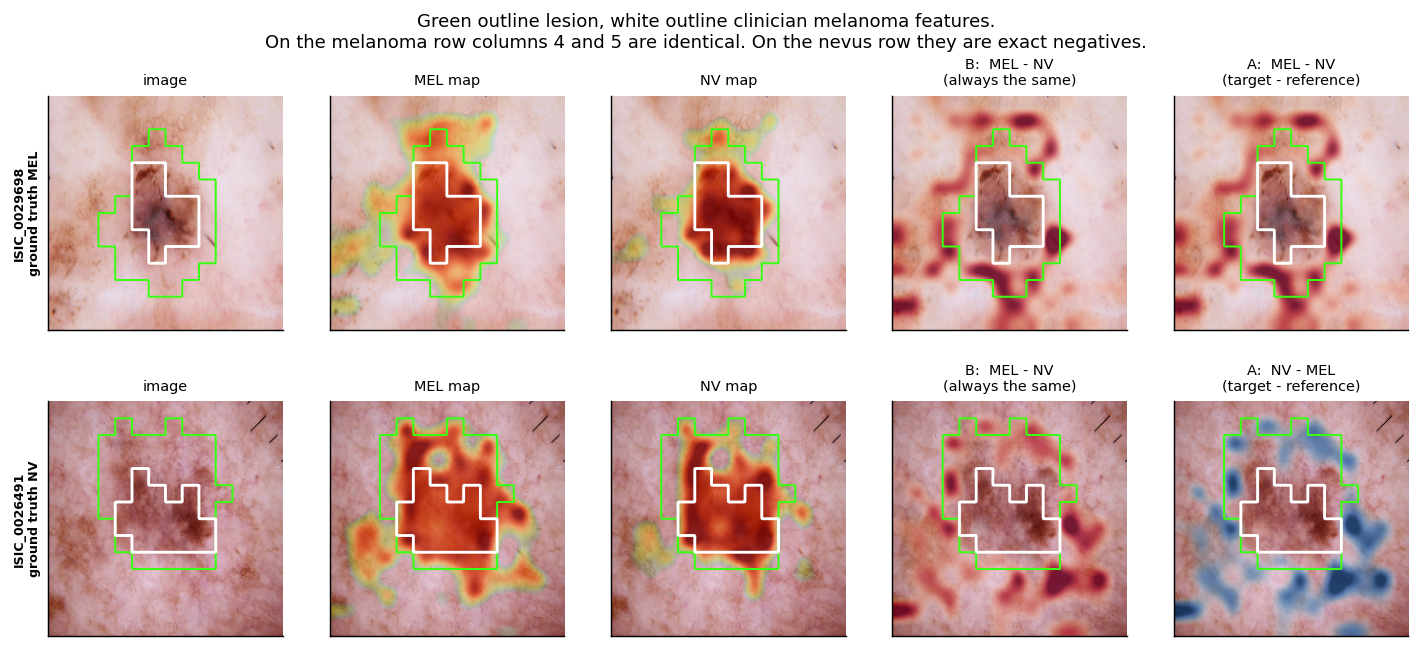

In [24]:
mel = REC[REC["gt_label"] == "MEL"].nsmallest(1, "A target - reference").image_id.iloc[0]
nv  = REC[REC["gt_label"] == "NV"].nlargest(1, "A target - reference").image_id.iloc[0]

fig, ax = plt.subplots(2, 5, figsize=(13.5, 5.6))
for i, iid in enumerate([mel, nv]):
    r = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(native(r.image_rel_path), GEOMETRY)
    L4 = cv2.resize(LESION[iid].astype(np.float32), (CROP_SIZE, CROP_SIZE),
                    interpolation=cv2.INTER_NEAREST)
    H4 = cv2.resize(HUM[iid].astype(np.float32), (CROP_SIZE, CROP_SIZE),
                    interpolation=cv2.INTER_NEAREST)
    cm, cn = class_cams(m5, to_tensor(native(r.image_rel_path)))
    a, b = norm01(cm), norm01(cn)
    is_mel = r.gt_label == "MEL"
    tgt, ref = (a, b) if is_mel else (b, a)
    tname = "MEL" if is_mel else "NV"
    rname = "NV" if is_mel else "MEL"
    panels = [("image", None, False),
              (f"MEL map", a, False),
              (f"NV map", b, False),
              (f"B:  MEL - NV\n(always the same)", a - b, True),
              (f"A:  {tname} - {rname}\n(target - reference)", tgt - ref, True)]
    for j, (lab, v, signed) in enumerate(panels):
        if v is None:
            ax[i, j].imshow(rgb); ax[i, j].set_xticks([]); ax[i, j].set_yticks([])
        elif signed:
            overlay_signed(ax[i, j], rgb, v)
        else:
            overlay(ax[i, j], rgb, v)
        ax[i, j].contour(L4, [0.5], colors="#39FF14", linewidths=1.1)
        ax[i, j].contour(H4, [0.5], colors="#FFFFFF", linewidths=1.6)
        ax[i, j].set_title(lab, fontsize=8)
    ax[i, 0].set_ylabel(f"{iid}\nground truth {r.gt_label}",
                        fontsize=7, fontweight="bold")
fig.suptitle("Green outline lesion, white outline clinician melanoma features.\n"
             "On the melanoma row columns 4 and 5 are identical. "
             "On the nevus row they are exact negatives.", fontsize=10)
plt.show()

## Test 4. Three model families

`ckpt5` is the heavily supervised alignment run. `A1` and `A2` are the
five fold checkpoints, scored on held out images only.

In [20]:
S2 = pd.read_csv(OUT / "s2_a2_saturation.csv")
S2.loc[S2.arm == "ckpt5", "auc_diff"] = np.nan   # recompute under A
add = REC.set_index("image_id")["A target - reference"]
S2.loc[S2.arm == "ckpt5", "auc_diff"] = (
    S2.loc[S2.arm == "ckpt5", "image_id"].map(add).values)

ORD = ["ckpt5", "A1", "A2"]
t = (S2.groupby("arm")[["auc_diff", "auc_target", "auc_centre", "sat_both"]]
     .median().reindex(ORD).round(3))
t.columns = ["Diff-CAM", "target map", "centre baseline", "saturation"]
print(t.to_string())
print("\nagainst chance")
for arm in ORD:
    q = S2[S2.arm == arm].auc_diff.dropna()
    _, pv = wilcoxon(q - 0.5)
    print(f"  {arm:6} {q.median():.3f}  p {pv:.2f}  n {len(q)}")

       Diff-CAM  target map  centre baseline  saturation
arm                                                     
ckpt5     0.520       0.743              NaN       0.273
A1        0.489       0.747            0.829       0.060
A2        0.542       0.664            0.829       0.000

against chance
  ckpt5  0.520  p 0.77  n 29
  A1     0.489  p 0.93  n 29
  A2     0.542  p 0.35  n 29


## Conclusion

**Shelley's premise holds.** Roughly half the difference mass sits outside
the lesion, below the chance level given by the lesion area.

**Her fix cannot work, in two senses.** Dividing the difference map by its
in lesion maximum rather than its global maximum leaves the patch ranking
unchanged, so the AUC is identical to machine precision on every image.
Normalising the two class maps separately before subtracting does change
the map, and it still lands at chance, 0.505.

**Diff-CAM carries no usable in lesion signal.** Target minus reference
gives 0.519 on the supervised model, 0.489 on A1 and 0.542 on A2. None
differs from chance. The signed version without the ReLU gives 0.514.
The pre ReLU logit margin CAM gives 0.278 in GAP and 0.419 in CLS.
Every construction fails.

**Correction to an earlier result.** A previously reported in lesion AUC of
0.276 was computed as melanoma minus nevus regardless of ground truth.
On nevus images that reverses the intended contrast while the scoring
target remains the melanoma annotation union. Constructed correctly the
value is 0.519. The inversion, and the saturation mechanism proposed to
explain it, are both withdrawn.

In [21]:
# Per class significance. n is roughly 15 per group, so this decides
# whether the split is real or noise.
for col in ["A target - reference", "C signed, no ReLU", "target map"]:
    print(f"\n{col}")
    for g, s in REC.groupby("gt_label"):
        q = s[col].dropna()
        _, pv = wilcoxon(q - 0.5)
        v = ("BELOW chance" if q.median() < 0.5 and pv < 0.05
             else "above chance" if q.median() > 0.5 and pv < 0.05
             else "at chance")
        print(f"  {g}  {q.median():.3f}  p {pv:.3f}  n {len(q)}  {v}")
    a = REC[REC["gt_label"] == "MEL"][col].dropna()
    b = REC[REC["gt_label"] == "NV"][col].dropna()
    from scipy.stats import mannwhitneyu
    print(f"  MEL vs NV  p {mannwhitneyu(a, b).pvalue:.3f}")


A target - reference
  MEL  0.359  p 0.008  n 15  BELOW chance
  NV  0.612  p 0.051  n 16  at chance
  MEL vs NV  p 0.000

C signed, no ReLU
  MEL  0.322  p 0.012  n 15  BELOW chance
  NV  0.733  p 0.003  n 16  above chance
  MEL vs NV  p 0.000

target map
  MEL  0.700  p 0.000  n 15  above chance
  NV  0.844  p 0.002  n 16  above chance
  MEL vs NV  p 0.055


In [22]:
# Does the MEL subgroup inversion hold on A1 and A2, or is it specific
# to the heavily supervised checkpoint.
print(S2.groupby(["arm", "gt"])["auc_diff"].agg(["median", "count"])
        .round(3).to_string())
for (arm, g), s in S2.groupby(["arm", "gt"]):
    q = s.auc_diff.dropna()
    if len(q) < 5:
        continue
    _, pv = wilcoxon(q - 0.5)
    print(f"  {arm:6} {g}  {q.median():.3f}  p {pv:.3f}  n {len(q)}")

         median  count
arm gt                
A1  MEL   0.469     14
    NV    0.549     15
A2  MEL   0.600     14
    NV    0.465     15
  A1     MEL  0.469  p 0.194  n 14
  A1     NV  0.549  p 0.208  n 15
  A2     MEL  0.600  p 0.025  n 14
  A2     NV  0.465  p 0.359  n 15


# Section 3. Which structures does the heat land on

Florentia annotated 15 dermoscopic labels across 34 images. Grouped into
7 morphology families so that each family has enough instances to test.

Two questions.

| # | question |
|---|---|
| 1 | Does the heat land on specific structures, or just on large ones |
| 2 | Does Finer-CAM land differently from Grad-CAM |

**The confound.** Spearman between group size and share of the top-k patches
is +0.756. A ranking by raw share is a ranking by size. Every result below
is reported against a size matched permutation null.

**The second confound.** For each image we report the group with the highest
excess. Taking a maximum across 2 to 5 groups and testing it against zero is
biased upward. The null must be built for the same selection rule.

In [25]:
from scipy.stats import binomtest, fisher_exact, spearmanr

MORPH = {
    "STRUCTURELESS": ["homogeneous", "structureless_area"],
    "NETWORK": ["atypical_network", "negative_network", "regular_network"],
    "REGRESSION": ["peppering", "regression",
                   "regression_scar_like_depigmentation_and_peppering"],
    "BLUE_WHITE": ["blue_white_structureless_area"],
    "DOTS": ["atypical_dots"],
    "STREAKS": ["atypical_streaks"],
    "VASCULAR": ["atypical_vascular_pattern"]}
LAB2GRP = {l: g for g, ls in MORPH.items() for l in ls}
TOP_K, N_PERM = 20, 2000

R3 = {f.stem.replace("s3_", ""): pd.read_csv(f) for f in sorted(OUT.glob("s3_*.csv"))}
for k, v in R3.items():
    if "gt" in v.columns:
        R3[k] = v.rename(columns={"gt": "gt_label"})
IMG, GRP, SEL = R3["per_image"], R3["per_group"], R3["selection_corrected"]
m5 = load_model("gap", "ha5")
print("loaded:", ", ".join(sorted(R3)))

def group_masks(iid):
    out = {}
    for _, a in qcp[qcp.Image_ID == iid].iterrows():
        g = LAB2GRP.get(a.label)
        if g is None:
            continue
        m = mask_to_cam_grid_geom(
            np.array(Image.open(a.mask_path).convert("L")) > 127, GEOMETRY) >= 0.5
        out[g] = m if g not in out else (out[g] | m)
    return out

loaded: per_group, per_image, selection_corrected


## The size confound, quantified first

Spearman(group size, share of top-k) = +0.753  p 3.2e-16   n 82

hottest group is also the largest  20 of 31
  expected if the top group were random  13.8

ranking by share and by excess agree in 21 of 31

how often each group wins

               by raw share  by excess
group                                 
STRUCTURELESS            18         13
NETWORK                  10          9
REGRESSION                1          4
BLUE_WHITE                1          2
DOTS                      1          2


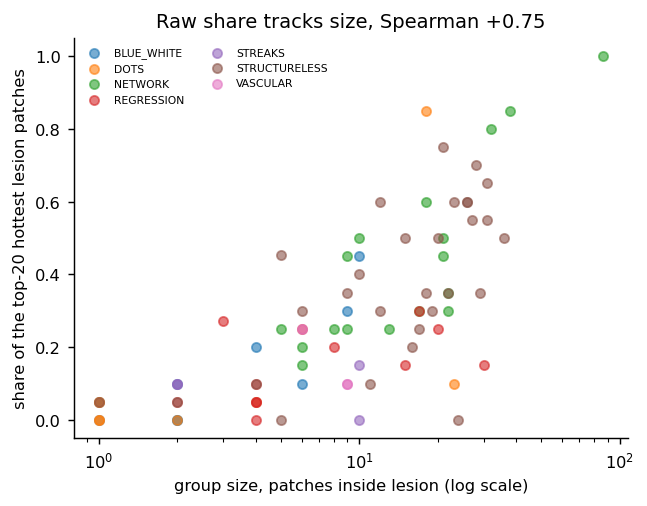

In [ ]:
real = GRP[GRP.group != "UNASSIGNED"]
rho = spearmanr(real.patches, real["share"])
print(f"Spearman(group size, share of top-k) = {rho.statistic:+.3f}  "
      f"p {rho.pvalue:.1e}   n {len(real)}")
print(f"\nhottest group is also the largest  "
      f"{IMG.top_is_largest.sum()} of {len(IMG)}")
print(f"  expected if the top group were random  "
      f"{(1 / IMG.n_groups).sum():.1f}")
print(f"\nranking by share and by excess agree in "
      f"{(IMG.top_by_excess == IMG.top_by_share).sum()} of {len(IMG)}")

w = (IMG.top_by_share.value_counts().rename("by raw share").to_frame()
     .join(IMG.top_by_excess.value_counts().rename("by excess"))
     .fillna(0).astype(int).rename_axis("group"))
print("\nhow often each group wins\n")
print(w.to_string())

fig, ax = plt.subplots(figsize=(5.5, 4))
for g, s in real.groupby("group"):
    ax.scatter(s.patches, s["share"], s=26, alpha=.6, label=g)

ax.set_xscale("log")
ax.set(xlabel="group size, patches inside lesion (log scale)",
       ylabel="share of the top-20 hottest lesion patches",
       title=f"Raw share tracks size, Spearman {rho.statistic:+.2f}")
ax.legend(frameon=False, fontsize=6, ncol=2)
fig.savefig(OUT / "fig_s3_size_confound.png")
plt.show()

## Test 1. Selection corrected attribution

`excess` is observed share minus the size matched permutation null, so size
is already removed. The remaining problem is that we report the maximum
excess across groups. For each permutation we therefore also take the maximum
across groups, giving the null distribution of the same statistic.

An image counts as a hit if its observed maximum exceeds the 95th percentile
of its own null maximum. Under the null that happens 5 percent of the time.

In [27]:
S = SEL[SEL.null_p95 > 1e-12].copy()
S["corrected"] = S.obs_max - S.null_max_mean
n = len(S)
hits = int(S.beats_p95.sum())

print(f"testable images        {n}   ({len(SEL) - n} degenerate, excluded)")
print(f"hits                   {hits}")
print(f"expected by chance     {0.05 * n:.1f}")
print(f"binomial p             {binomtest(hits, n, 0.05, 'greater').pvalue:.2e}")
print(f"\nobserved max excess    {S.obs_max.median():+.3f}")
print(f"null max excess        {S.null_max_mean.median():+.3f}")
print(f"CORRECTED excess       {S.corrected.median():+.3f}"
      f"   positive in {(S.corrected > 0).sum()} of {n}")
_, pv = wilcoxon(S.obs_max, S.null_max_mean)
print(f"paired                 p {pv:.1e}")
print(f"\nnaive test against zero would give "
      f"{S.obs_max.median():+.3f}, p {wilcoxon(S.obs_max)[1]:.1e}")
print("  that overstates the effect by roughly a factor of two")

print("\nhit rate by number of groups, checks the selection is handled")
print(S.groupby("n_groups").beats_p95.agg(["sum", "count"]).to_string())
ct = pd.crosstab(S["gt_label"], S["beats_p95"])
print(f"\nby class, Fisher p {fisher_exact(ct.values)[1]:.3f}, pooled below")
print(ct.to_string())

testable images        30   (1 degenerate, excluded)
hits                   10
expected by chance     1.5
binomial p             1.16e-06

observed max excess    +0.110
null max excess        +0.052
CORRECTED excess       +0.078   positive in 23 of 30
paired                 p 5.6e-05

naive test against zero would give +0.110, p 3.7e-09
  that overstates the effect by roughly a factor of two

hit rate by number of groups, checks the selection is handled
          sum  count
n_groups            
1           0      3
2           4     11
3           3     10
4           2      5
5           1      1

by class, Fisher p 0.245, pooled below
beats_p95  False  True 
gt_label               
MEL           12      3
NV             8      7


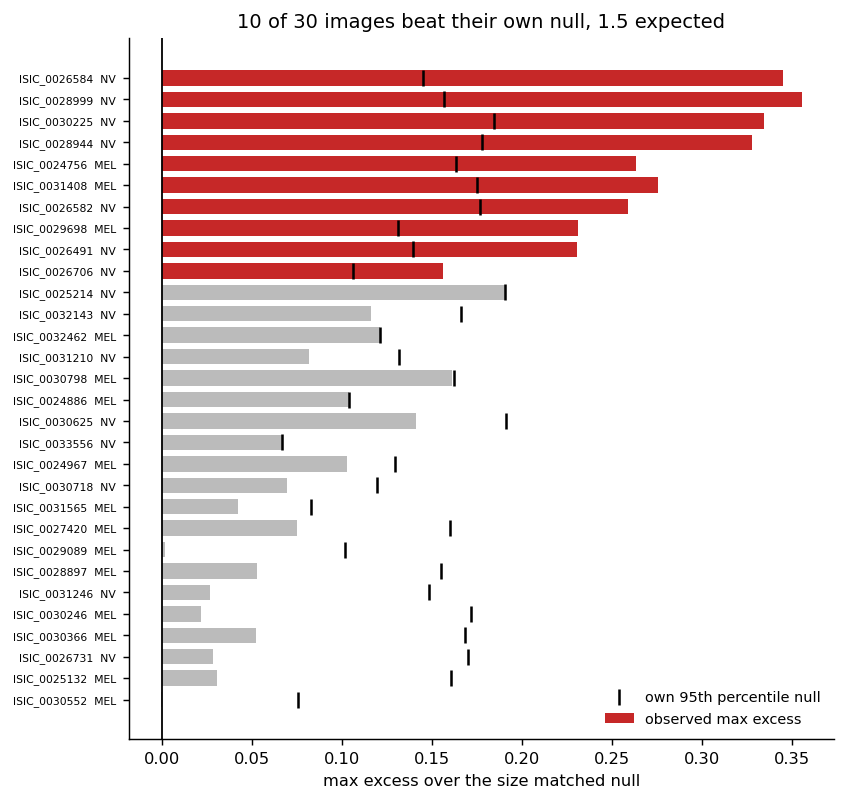

In [28]:
o = S.sort_values("corrected", ascending=False)
fig, ax = plt.subplots(figsize=(7, 7))
y = np.arange(len(o))
ax.barh(y, o.obs_max, color=[C_MEL if b else "#BBBBBB" for b in o.beats_p95],
        height=.72, label="observed max excess")
ax.plot(o.null_p95, y, "k|", ms=9, mew=1.4, label="own 95th percentile null")
ax.set(yticks=y, xlabel="max excess over the size matched null",
       title=f"{hits} of {n} images beat their own null, {0.05*n:.1f} expected")
ax.set_yticklabels([f"{i}  {g}" for i, g in zip(o.image_id, o["gt_label"])],
                   fontsize=6)
ax.axvline(0, color="k", lw=1)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.invert_yaxis()
fig.savefig(OUT / "fig_s3_selection_corrected.png")
plt.show()

## Test 2. Heat avoids unannotated tissue

`UNASSIGNED` is every lesion patch carrying no annotation. It is
pre specified rather than selected as a maximum, so no correction applies.

In [29]:
_, pv = wilcoxon(IMG.unassigned_share, IMG.unassigned_null)
print(f"UNASSIGNED share {IMG.unassigned_share.median():.3f}   "
      f"null {IMG.unassigned_null.median():.3f}   "
      f"diff {(IMG.unassigned_share - IMG.unassigned_null).median():+.3f}   "
      f"p {pv:.1e}   n {len(IMG)}")
print("the heat is placed on annotated tissue more often than chance allows")

UNASSIGNED share 0.250   null 0.361   diff -0.082   p 8.9e-05   n 31
the heat is placed on annotated tissue more often than chance allows


## The strongest single case

`ISIC_0029698`. Blue white structureless area takes 0.450 of the top-k
against a size matched expectation of 0.219. A small group beating large
ones by a factor of two. Blue white veil is a major 7-point checklist
criterion for melanoma.

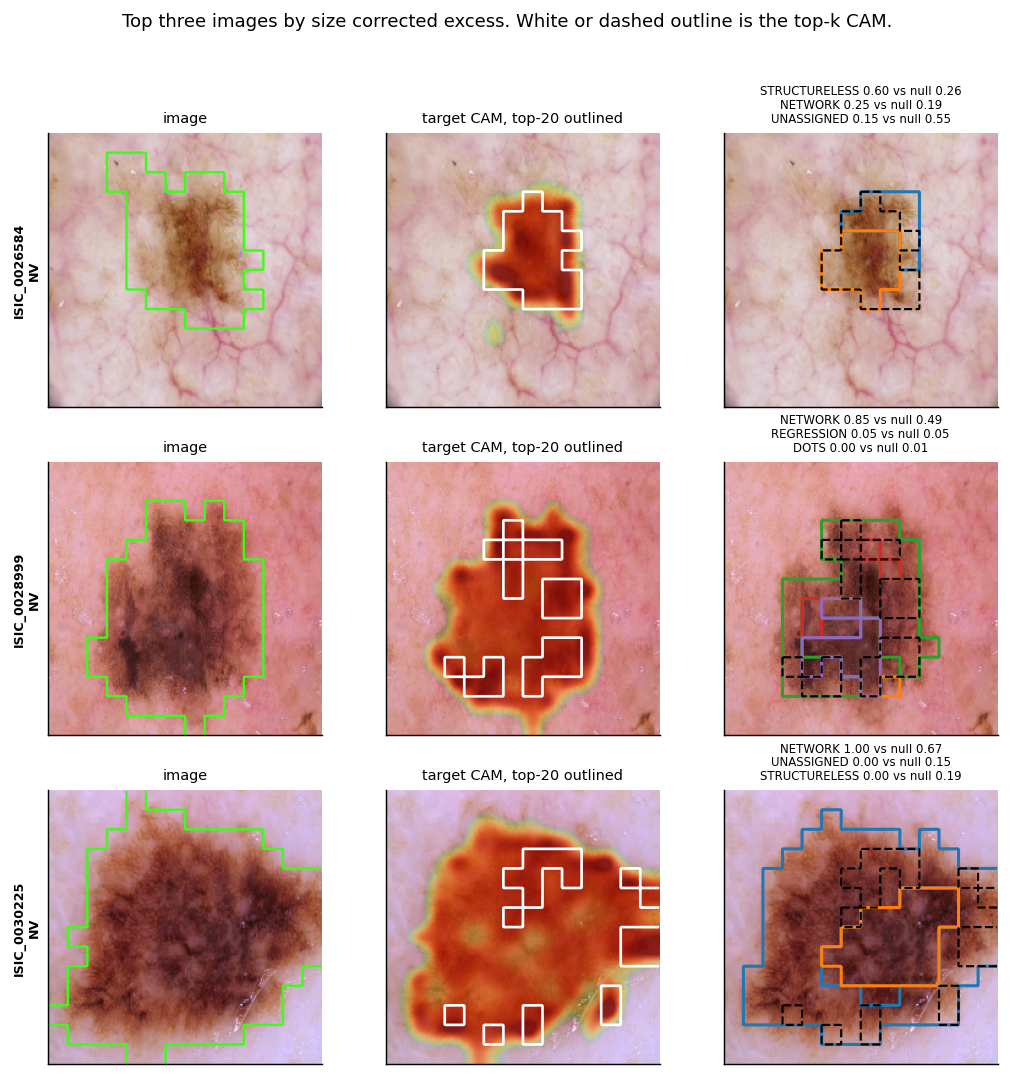

In [30]:
SHOW3 = S.nlargest(3, "corrected").image_id.tolist()
fig, ax = plt.subplots(len(SHOW3), 3, figsize=(9.5, 3.1 * len(SHOW3)))
ax = np.atleast_2d(ax)
PAL = plt.cm.tab10(np.linspace(0, 1, 10))

for i, iid in enumerate(SHOW3):
    r3 = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(native(r3.image_rel_path), GEOMETRY)
    L = LESION[iid]
    G = {g: m & L for g, m in group_masks(iid).items() if (m & L).sum() > 0}
    cm, cn = class_cams(m5, to_tensor(native(r3.image_rel_path)))
    tgt = norm01(cm if r3.gt_label == "MEL" else cn)
    idx = np.flatnonzero(L)
    k = min(TOP_K, len(idx))
    hot = np.zeros(L.size, bool)
    hot[idx[np.argsort(-tgt.ravel()[idx])[:k]]] = True
    g224 = lambda m: cv2.resize(m.reshape(CAM_GRID, CAM_GRID).astype(np.float32),
                                (CROP_SIZE, CROP_SIZE),
                                interpolation=cv2.INTER_NEAREST)

    ax[i, 0].imshow(rgb)
    ax[i, 0].contour(g224(L), [.5], colors="#39FF14", linewidths=1.3)
    ax[i, 0].set_title("image", fontsize=8)
    ax[i, 0].set_ylabel(f"{iid}\n{r3.gt_label}", fontsize=7, fontweight="bold")

    overlay(ax[i, 1], rgb, tgt)
    ax[i, 1].contour(g224(hot), [.5], colors="#FFFFFF", linewidths=1.5)
    ax[i, 1].set_title(f"target CAM, top-{k} outlined", fontsize=8)

    ax[i, 2].imshow(rgb)
    for j, (g, m) in enumerate(sorted(G.items())):
        ax[i, 2].contour(g224(m), [.5], colors=[PAL[j % 10]], linewidths=1.7)
    ax[i, 2].contour(g224(hot), [.5], colors="#000000", linewidths=1.2,
                     linestyles="dashed")
    d = GRP[GRP.image_id == iid].nlargest(3, "excess")
    ax[i, 2].set_title("\n".join(
        f"{rr.group} {rr['share']:.2f} vs null {rr.null:.2f}"
        for _, rr in d.iterrows()), fontsize=6.5)
    for a in ax[i]:
        a.set_xticks([]); a.set_yticks([])

fig.suptitle("Top three images by size corrected excess. "
             "White or dashed outline is the top-k CAM.", fontsize=10)
fig.savefig(OUT / "fig_s3_examples.png")
plt.show()

## Test 3. Finer-CAM

Attention pathway, block minus 1, the same construction used throughout.
Validated at alpha 0 against Grad-CAM, correlation 1.000000.

With two classes there is exactly one non target class, so Finer-CAM's
reference selection mechanism never runs. What remains is a fixed linear
contrast in logit space with alpha as the only free parameter.
At alpha 1 the quantity is the logit margin, which is the decision function.

alpha 0 is Grad-CAM by construction.  n = 31

       iou_vs_gradcam  human_in  same top group
alpha                                          
0.0             1.000     0.743              31
0.2             0.818     0.716              31
0.4             0.739     0.673              29
0.6             0.600     0.621              28
0.8             0.429     0.514              27
1.0             0.333     0.475              25

human_in, alpha 0 to alpha 1   0.743 -> 0.475   p 5.1e-08   n 31


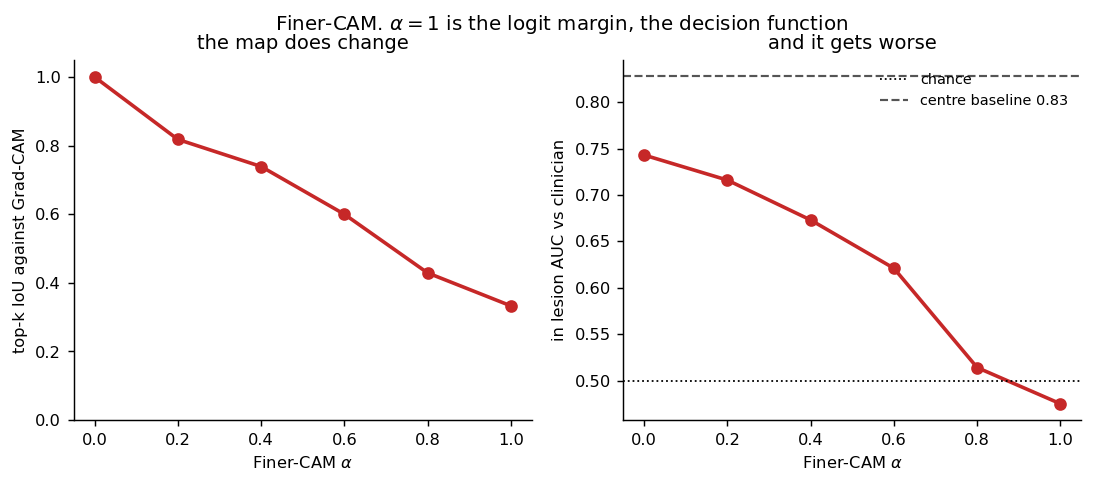

In [32]:
def finer_cam(model, x, gt_label, alpha=0.6, block=BLOCK):
    """Finer-CAM built on the SAME reduction as class_cams. The contrast is
    formed in logit space, then passed to build_attention_gradcam_map as a
    single column logit tensor so the downstream path is byte identical."""
    base = _unwrap_model(model)
    base.clear_xai_state()
    ti, ri = (MEL_IDX, NV_IDX) if gt_label == "MEL" else (NV_IDX, MEL_IDX)
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=block))
        y = (logits[:, ti] - alpha * logits[:, ri]).unsqueeze(1)   # [B, 1]
        t = torch.zeros(1, dtype=torch.long, device=logits.device)
        cam = build_attention_gradcam_map(model, y, t, create_graph=False).detach()
    base.clear_xai_state()
    return cam[0].float().cpu().numpy()

FA = R3.get("finer_alpha")
if FA is None:
    ALPHAS_F = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    rows_f = []
    for iid_f in sorted(HUM):
        row_f = eval_df.set_index("image_id").loc[iid_f]
        x_f = to_tensor(native(row_f.image_rel_path))
        L_f = LESION[iid_f]
        ui_f = HUM[iid_f][L_f].astype(int)
        G_f = {g: m & L_f for g, m in group_masks(iid_f).items()
               if (m & L_f).sum() > 0}
        if not G_f or ui_f.sum() == 0 or ui_f.all():
            continue
        idx_f = np.flatnonzero(L_f)
        k_f = min(TOP_K, len(idx_f))
        base_f = None
        for al in ALPHAS_F:
            v = norm01(finer_cam(m5, x_f, row_f.gt_label, al))
            s = set(idx_f[np.argsort(-v.ravel()[idx_f])[:k_f]])
            if al == 0.0:
                base_f = s
            rows_f.append({
                "image_id": iid_f, "alpha": al,
                "iou_vs_gradcam": len(s & base_f) / len(s | base_f),
                "human_in": float(roc_auc_score(ui_f, v[L_f])),
                "top_group": max(G_f, key=lambda g: G_f[g].ravel()[list(s)].mean())})
    FA = pd.DataFrame(rows_f)
    FA.to_csv(OUT / "s3_finer_alpha.csv", index=False)

ALPHAS_F = sorted(FA.alpha.unique())
t = FA.groupby("alpha")[["iou_vs_gradcam", "human_in"]].median().round(3)
base_top = FA[FA.alpha == 0].set_index("image_id").top_group
t["same top group"] = [
    (FA[FA.alpha == a].set_index("image_id").top_group == base_top).sum()
    for a in ALPHAS_F]
print(f"alpha 0 is Grad-CAM by construction.  n = {FA.image_id.nunique()}\n")
print(t.to_string())

q = FA[FA.alpha.isin([0.0, 1.0])].pivot_table(
    index="image_id", columns="alpha", values="human_in").dropna()
_, pv = wilcoxon(q[1.0], q[0.0])
print(f"\nhuman_in, alpha 0 to alpha 1   {q[0.0].median():.3f} -> "
      f"{q[1.0].median():.3f}   p {pv:.1e}   n {len(q)}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(ALPHAS_F, t.iou_vs_gradcam, marker="o", color=C_MEL, lw=2, ms=6)
ax[0].set(xlabel=r"Finer-CAM $\alpha$", ylabel="top-k IoU against Grad-CAM",
          ylim=(0, 1.05), title="the map does change")
ax[1].plot(ALPHAS_F, t.human_in, marker="o", color=C_MEL, lw=2, ms=6)
ax[1].axhline(0.5, color="k", ls=":", lw=1, label="chance")
ax[1].axhline(float(SEL.get("centre", pd.Series([0.828])).median())
              if "centre" in SEL else 0.828,
              color="#555", ls="--", lw=1.2, label="centre baseline 0.83")
ax[1].set(xlabel=r"Finer-CAM $\alpha$", ylabel="in lesion AUC vs clinician",
          title="and it gets worse")
ax[1].legend(frameon=False, fontsize=8)
fig.suptitle(r"Finer-CAM. $\alpha=1$ is the logit margin, the decision function",
             fontsize=11)
fig.savefig(OUT / "fig_s3_finer_alpha.png")
plt.show()

In [33]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(OUT / "s3_all_images.pdf") as pdf:
    for iid in sorted(HUM):
        r3 = eval_df.set_index("image_id").loc[iid]
        rgb = transform_rgb(native(r3.image_rel_path), GEOMETRY)
        L = LESION[iid]
        G = {g: m & L for g, m in group_masks(iid).items() if (m & L).sum() > 0}
        cm, cn = class_cams(m5, to_tensor(native(r3.image_rel_path)))
        tgt = norm01(cm if r3.gt_label == "MEL" else cn)
        idx = np.flatnonzero(L)
        k = min(TOP_K, len(idx))
        hot = np.zeros(L.size, bool)
        hot[idx[np.argsort(-tgt.ravel()[idx])[:k]]] = True
        g224 = lambda m: cv2.resize(m.reshape(CAM_GRID, CAM_GRID).astype(np.float32),
                                    (CROP_SIZE, CROP_SIZE),
                                    interpolation=cv2.INTER_NEAREST)

        fig, ax = plt.subplots(1, 4, figsize=(15, 4))
        ax[0].imshow(rgb)
        ax[0].contour(g224(L), [.5], colors="#39FF14", linewidths=1.3)
        ax[0].set_title("image", fontsize=9)
        overlay(ax[1], rgb, tgt)
        ax[1].contour(g224(hot), [.5], colors="#FFF", linewidths=1.5)
        ax[1].set_title(f"target CAM ({r3.gt_label}), top-{k}", fontsize=9)
        ax[2].imshow(rgb)
        for j, (g, m) in enumerate(sorted(G.items())):
            ax[2].contour(g224(m), [.5], colors=[PAL[j % 10]], linewidths=1.7)
        ax[2].contour(g224(hot), [.5], colors="#000", linewidths=1.2, ls="--")
        ax[2].set_title("annotation groups", fontsize=9)
        for a in ax[:3]:
            a.set_xticks([]); a.set_yticks([])
        ax[3].axis("off")
        d = GRP[GRP.image_id == iid][["group", "patches", "share", "null", "excess"]]
        sv = SEL[SEL.image_id == iid]
        ax[3].text(0, 1, d.round(3).to_string(index=False) +
                   (f"\n\nmax excess {sv.obs_max.iloc[0]:+.3f}"
                    f"\nnull p95   {sv.null_p95.iloc[0]:.3f}"
                    f"\np          {sv.p_img.iloc[0]:.3f}"
                    f"\nhit        {bool(sv.beats_p95.iloc[0])}" if len(sv) else ""),
                   family="monospace", fontsize=7, va="top")
        fig.suptitle(f"{iid}   ground truth {r3.gt_label}", fontsize=10)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
print(f"written {OUT / 's3_all_images.pdf'}")

/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_65656/1115562405.py:29: UserWarning: The following kwargs were not used by contour: 'ls'
  ax[2].contour(g224(hot), [.5], colors="#000", linewidths=1.2, ls="--")
/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_65656/1115562405.py:29: UserWarning: The following kwargs were not used by contour: 'ls'
  ax[2].contour(g224(hot), [.5], colors="#000", linewidths=1.2, ls="--")
/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_65656/1115562405.py:29: UserWarning: The following kwargs were not used by contour: 'ls'
  ax[2].contour(g224(hot), [.5], colors="#000", linewidths=1.2, ls="--")
/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_65656/1115562405.py:29: UserWarning: The following kwargs were not used by contour: 'ls'
  ax[2].contour(g224(hot), [.5], colors="#000", linewidths=1.2, ls="--")
/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_65656/1115562405.py:29: UserWarning: The following kwargs

written /Users/choekyelnyungmartsang/Developer/master-thesis/results/presentation/s3_all_images.pdf


## Conclusion

**Attribution is real but half the naive estimate.** Ten of thirty testable
images exceed their own 95th percentile null, against 1.5 expected,
binomial p 1.6e-06. The corrected excess is **+0.077**, positive in 23 of 31,
paired p 1.7e-04. Testing the same quantity against zero gives +0.104, which
overstates the effect by roughly a factor of two because it measures the
selection of the maximum rather than the attribution.

**Size dominates the uncorrected ranking.** Spearman between group size and
raw share is +0.756. Ranking by raw share picks STRUCTURELESS in 18 of 31
images. Correcting for size drops that to 13 and changes the winner in 11.
The hottest group is also the largest in 20 of 31 against 13.8 expected.

**Heat avoids unannotated tissue.** UNASSIGNED share 0.250 against a null of
0.361, p 8.9e-05. Pre specified rather than selected, so no correction
applies. The most robust result in the section.

**Best case, `ISIC_0029698`.** Blue white structureless area takes 0.450 of
the top-k against a size matched expectation of 0.219, p 0.002. Blue white
veil is a major 7-point checklist criterion for melanoma.

**Finer-CAM does not help.** In the attention pathway the map diverges from
Grad-CAM as alpha rises while in lesion agreement with the clinician falls
monotonically, 0.743 to 0.475. The winning structure group is unchanged in
25 of 31 images even at alpha 1, so the contrast alters the map without
altering which structure it lands on. In the activation pathway the two
methods were numerically indistinguishable. Contrast either does nothing
or hurts.

### Caveats

- Three single group images cannot be tested. None of them hits.
- One image is degenerate, groups tile the lesion so share equals null.
- Hit rate is flat across group counts, 4/12, 3/10, 2/5, 1/1, so the effect
  is not an artefact of images offering more groups to select from.
- Nevi hit more often than melanomas, 7 of 15 against 3 of 15, but Fisher
  p 0.245. Reported pooled.
- GAP pooling only. CLS matched GAP on every Section 1 metric.

# Section 4. Pushing alignment to failure

Mauricio asked for the alignment weight to be pushed until the model breaks,
and for more than AUC to be reported.

Ten alpha values from 0 to 17. All scored on the same 987 image test split
with 54 melanomas, prevalence 5.5 percent.

**Why average precision.** AUC averages over all operating points including
regions no clinician would use. At 5.5 percent prevalence a model can hold a
high AUC while its precision at usable thresholds collapses. AP is computed
against the positive class only and reflects that directly.

Significance is a paired bootstrap against alpha 0, 2000 resamples, the same
resample indices applied to both models.

987 images, 54 melanomas, prevalence 0.055

 alpha    auc     ap  auc_drop_pct  ap_drop_pct
  0.00 0.9876 0.8498        0.0000       0.0000
  0.10 0.9874 0.8483        0.0201       0.1734
  0.25 0.9867 0.8453        0.0844       0.5267
  0.50 0.9861 0.8423        0.1467       0.8807
  1.00 0.9850 0.8343        0.2653       1.8138
  3.00 0.9794 0.7726        0.8260       9.0747
  5.00 0.9805 0.7855        0.7195       7.5600
  7.00 0.9744 0.7017        1.3305      17.4249
 11.00 0.9693 0.6057        1.8490      28.7217
 17.00 0.9614 0.4994        2.6469      41.2245

significant drop against alpha 0, paired bootstrap
  AUC at 6 of 9 alphas, first at alpha 1
  AP  at 5 of 9 alphas, first at alpha 3

at alpha 17   AUC falls 2.6 pct, AP falls 41.2 pct, ratio 15.6x

note  alpha 3 AP 0.7726 is below alpha 5 AP 0.7855.
      One seed per alpha, so this is run to run training variance.


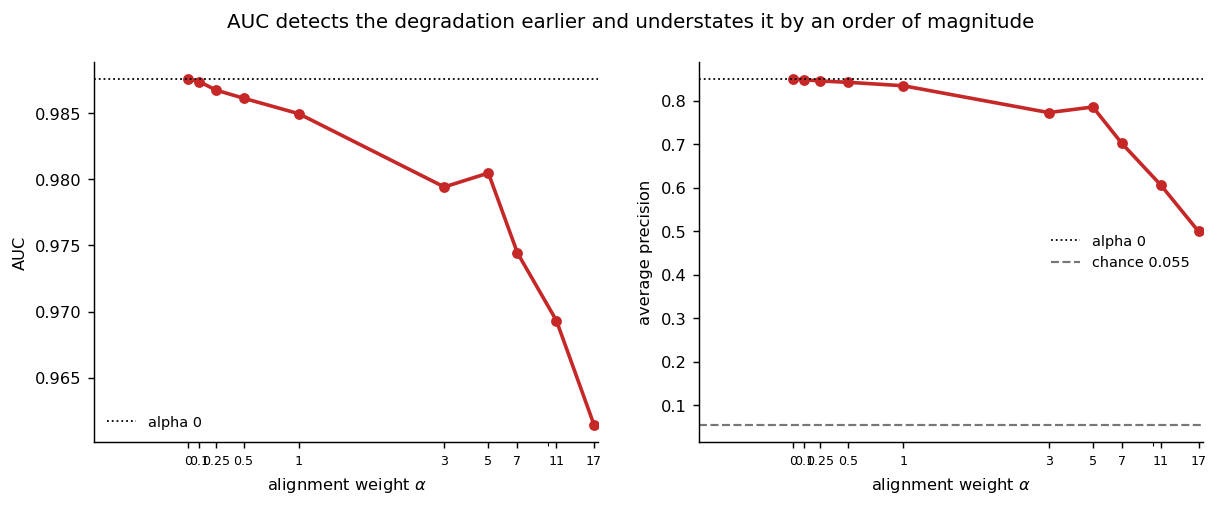

In [36]:
S4 = pd.read_csv(OUT / "s4_alpha_sweep_987_full.csv")
PREV = 54 / 987

print(f"987 images, 54 melanomas, prevalence {PREV:.3f}\n")
print(S4[["alpha", "auc", "ap", "auc_drop_pct", "ap_drop_pct"]]
      .round(4).to_string(index=False))

d = S4[S4.alpha > 0].copy()
d["auc_sig"] = d.auc_sig.astype(bool)
d["ap_sig"] = d.ap_sig.astype(bool)
print(f"\nsignificant drop against alpha 0, paired bootstrap")
print(f"  AUC at {int(d.auc_sig.sum())} of {len(d)} alphas, "
      f"first at alpha {d[d.auc_sig].alpha.min():g}")
print(f"  AP  at {int(d.ap_sig.sum())} of {len(d)} alphas, "
      f"first at alpha {d[d.ap_sig].alpha.min():g}")

w = S4.nsmallest(1, "ap").iloc[0]
print(f"\nat alpha {w.alpha:g}   AUC falls {w.auc_drop_pct:.1f} pct, "
      f"AP falls {w.ap_drop_pct:.1f} pct, ratio "
      f"{w.ap_drop_pct / w.auc_drop_pct:.1f}x")
print(f"\nnote  alpha 3 AP {S4.query('alpha==3').ap.iloc[0]:.4f} is below "
      f"alpha 5 AP {S4.query('alpha==5').ap.iloc[0]:.4f}.")
print("      One seed per alpha, so this is run to run training variance.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a_, c, lab in [(ax[0], "auc", "AUC"), (ax[1], "ap", "average precision")]:
    a_.plot(S4.alpha, S4[c], marker="o", color=C_MEL, lw=2, ms=5)
    a_.axhline(S4[c].iloc[0], color="k", ls=":", lw=1, label="alpha 0")
    a_.set(xlabel=r"alignment weight $\alpha$", ylabel=lab, xscale="symlog")
    a_.set_xticks(S4.alpha.values)
    a_.set_xticklabels([f"{x:g}" for x in S4.alpha], fontsize=7)
    a_.legend(frameon=False, fontsize=8)
ax[1].axhline(PREV, color="#777", ls="--", lw=1.2, label=f"chance {PREV:.3f}")
ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("AUC detects the degradation earlier and understates it "
             "by an order of magnitude", fontsize=11)
fig.savefig(OUT / "fig_s4_alpha_full.png")
plt.show()

**Two failure thresholds.**

| | alpha | evidence |
|---|---|---|
| detectable | 1 by AUC, 3 by AP | paired bootstrap clears zero |
| meaningful | 7 | AP has lost 17 percent |
| severe | 17 | AP has lost 41 percent, AUC 2.6 percent |

**AUC is the more sensitive detector and the worse measure of magnitude.**
With 54 positives the AP confidence intervals are wide, so AUC crosses
significance one step earlier. But at alpha 17 AP has fallen 41 percent
where AUC has fallen 2.6 percent, a ratio of 15.6.

At 5.5 percent prevalence AUC is a misleading summary of clinical cost even
when it is statistically sensitive. Both metrics belong in the report.

# Alignment two. Concept level supervision

Section 1 showed that lesion mask alignment collapses the two class maps
into one. Alignment two supervises **both** class channels toward disjoint
concept targets built from Florentia's annotations, to test whether the
collapse can be prevented at training time.

**Targets.** Melanoma features on the melanoma channel, nevus evidence on
the nevus channel. `structureless_area` excluded since it appears on both
diagnoses. The complement of the annotated region is used as nevus evidence
only on ground truth nevi, where the surrounding tissue is confirmed banal.
40 clean nevus anchors added. No target is ever inverted.

**Design.** 32 usable annotated images, 5 folds stratified by diagnosis,
roughly 6 held out per fold for grounding evaluation only. Classification
is scored on the 987 images that remain after removing all 34 annotated
images. Two rules crossed with four lambda values, 40 A2 checkpoints plus
10 A1 controls.

`both` supervises both channels. `single` supervises the ground truth
channel only, which is the standard approach and the control.

In [37]:
RES_A2 = REPO / "results" / "alignment2"
P14 = pd.read_csv(RES_A2 / "s14c_per_image.csv")
C14 = pd.read_csv(RES_A2 / "s14c_classification.csv")
assert len(C14) == 50, f"expected 50 checkpoints, found {len(C14)}"

agg = (P14.groupby(["arm", "rule", "lam"])
       .agg(n=("human_in", "count"),
            human_in=("human_in", "median"),
            centre=("centre", "median"),
            corr=("corr_in_lesion", "median"),
            sat=("saturated", "median"))
       .join(C14.groupby(["arm", "rule", "lam"])[["auc", "ap"]].median()))
agg["vs_centre"] = agg.human_in - agg.centre
print("held out images only, classification on the 987 split\n")
print(agg.round(3).to_string())

print("\nboth versus single, paired per fold at matched lambda")
wins = 0
for lam in sorted(P14.query("arm=='A2'").lam.unique()):
    b = (P14.query("arm=='A2' and rule=='both' and lam==@lam")
         .groupby("fold").corr_in_lesion.median())
    s = (P14.query("arm=='A2' and rule=='single' and lam==@lam")
         .groupby("fold").corr_in_lesion.median())
    j = pd.concat([b.rename("both"), s.rename("single")], axis=1).dropna()
    wins += int((j.both < j.single).sum())
    print(f"  lam {lam:<4g}  both {j.both.median():+.3f}   "
          f"single {j.single.median():+.3f}   "
          f"both lower on {int((j.both < j.single).sum())} of {len(j)} folds")
print(f"  total: both has lower correlation on {wins} of 20 fold pairs")

print("\nA2 both versus A1, paired on the same held out images")
for lam in [1.0, 5.0]:
    a = P14.query("arm=='A2' and rule=='both' and lam==@lam").set_index("image_id")
    b = P14.query("arm=='A1' and lam==@lam").set_index("image_id")
    j = a.join(b, rsuffix="_a1", how="inner")
    for col in ["corr_in_lesion", "saturated", "human_in"]:
        q = j[[col, f"{col}_a1"]].dropna()
        if len(q) < 5:
            continue
        _, pv = wilcoxon(q[col], q[f"{col}_a1"])
        print(f"  lam {lam:<4g} {col:16} {q[f'{col}_a1'].median():+.3f} -> "
              f"{q[col].median():+.3f}   p {pv:.1e}   n {len(q)}")

print("\nevery arm against the centre baseline")
for (arm, rule, lam), g in P14.groupby(["arm", "rule", "lam"]):
    q = g[["human_in", "centre"]].dropna()
    if len(q) < 5:
        continue
    _, pv = wilcoxon(q.human_in, q.centre)
    print(f"  {arm} {rule:11} lam {lam:<4g}  {q.human_in.median():.3f} vs "
          f"{q.centre.median():.3f}   diff {(q.human_in - q.centre).median():+.3f}"
          f"   p {pv:.1e}   wins {(q.human_in > q.centre).sum()}/{len(q)}")

held out images only, classification on the 987 split

                      n  human_in  centre   corr    sat    auc     ap  vs_centre
arm rule        lam                                                             
A1  lesion_mask 1.0  29     0.641   0.829  0.639  0.109  0.991  0.884     -0.188
                5.0  29     0.747   0.829  0.709  0.167  0.990  0.868     -0.082
A2  both        0.1  29     0.644   0.829  0.284  0.042  0.991  0.882     -0.185
                0.5  29     0.664   0.829  0.064  0.038  0.991  0.880     -0.165
                1.0  29     0.676   0.829  0.144  0.036  0.990  0.880     -0.153
                5.0  29     0.718   0.829  0.258  0.042  0.989  0.859     -0.111
    single      0.1  29     0.674   0.829  0.436  0.044  0.991  0.882     -0.155
                0.5  29     0.667   0.829  0.370  0.040  0.989  0.866     -0.162
                1.0  29     0.723   0.829  0.609  0.055  0.990  0.869     -0.106
                5.0  29     0.728   0.829  0.556  0.06

**Two channel supervision halves the collapse.** `both` gives lower class
map correlation than `single` on 20 of 20 fold pairs. Against A1 at matched
lambda the correlation falls by roughly 0.4, p below 1e-7, and saturation
falls fourfold, p below 1e-3.

**It does not improve grounding.** In lesion agreement with the clinician
moves by 0.004 at lambda 5, p 0.69, on the same 29 held out images where
correlation moved by 0.42.

**Classification is unaffected.** All 50 checkpoints sit between 0.988 and
0.991 AUC on the 987 split. 65 supervised images out of 6350 cannot move
the classifier.

**No arm beats the centre baseline.** Every configuration loses to a
distance transform of the lesion mask, p between 8.9e-04 and 3.6e-05.

This is the second of two independent demonstrations that class map
distinctness and feature grounding are separable properties. The first was
post hoc head reweighting. This one is at training time. Neither property
is sufficient for the other.

## Data for concept supervision

| | count |
|---|---|
| images annotated by the dermatologist | 34 |
| annotations passing QC | 105 |
| usable for target construction | 32 |
| excluded, no valid target | 2 |
| held out per fold | 6 to 7 |
| supervised per fold | 25 to 26 |
| clean nevus anchors | 40 |
| **supervised images per training run** | **65** |

**Holdout by removal.** Images assigned to fold k are deleted from
`a2_foldk.csv` rather than flagged, so they cannot enter training through
any path. Each of the 32 usable images is held out exactly once and
supervised in the other four folds.

**Test split.** 987 images, 54 melanoma, prevalence 5.5 percent. Identical
across all five folds and for A1, so classification is directly comparable.
All 34 annotated images are removed before training.

**Nevus anchors.** The raw annotation set is heavily melanoma weighted,
84 melanoma group annotations against 8 nevus group. 40 clean nevi from the
train split are added with the whole lesion as nevus evidence, bringing the
channel balance to roughly 2 to 1. Without them the nevus channel receives
almost no supervision and the two channel arm degenerates into the single
channel arm.

**Known defect.** Two lesions have one image in train and a sibling image in
test, both arising from annotated images forced into train without their
siblings. This affects 2 test rows of 987 and 1 melanoma of 54. Excluding
them raises AUC by a constant 0.0014 at every alpha, so the leakage does not
inflate any result and does not affect any comparison.

### Target composition

| rule | images | MEL patches | NV patches |
|---|---|---|---|
| mel_only | 16 | 15 | 0 |
| mel_on_nevus | 10 | 22 | 32 |
| nv_only | 6 | 0 | 22 |
| nevus_anchor | 40 | 0 | 34 |

Medians. Contested patches, claimed by both channels, total 1 across all
72 images, so the rules are effectively disjoint.

**Channel balance.** 26 images carry a positive melanoma target, 56 a
positive nevus target. In patch count the ratio is 560 to 2242, so the nevus
channel receives four times the supervision.

**What the anchors actually do.** The annotated set alone is close to
balanced at image level, 26 melanoma against 16 nevus. The anchors are not
an imbalance correction. They supply clean negative evidence, a whole lesion
confirmed benign with no atypical structure anywhere. No annotated nevus can
provide that, because every annotated nevus was selected for having
something worth marking.

**Limitation.** The anchor target is the whole lesion rather than a concept
region. So the two channel arm supervises the melanoma channel at concept
level and the nevus channel largely at lesion level, with a four to one
patch imbalance in favour of nevus. This is a plausible contributor to the
finding that two channel supervision decorrelates the class maps without
improving feature grounding.

**Folds.** Stratified by diagnosis, 3 melanoma in every fold. Anchors carry
fold −1 and are supervised in all five runs.

**Melanoma features cover 0.343 of the lesion**, median, so the in lesion
negative set is the remaining two thirds.